In [1]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Change this line to the directory where inputs are stored

INPUT_FILE= '/home/pbeamer/Documents/h5ad/graphst/V1_Human_Invasive_Ductal_Carcinoma_10xvisium_processed_graphst.h5ad'

#Set fields of anndata where ground truth and embedding for clustering are stored
EMBEDDING = 'X_gst'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = [0.15,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6]
RES_KEYS = [f'leiden_{r:.3f}' for r in RESOLUTIONS]
GROUND_TRUTH = 'clusters'

In [3]:

#Run clusterings for each resolution and save
'''
Preprocess leiden clusterings for given dataset

Arguments: 
input_file: path to the input file
output_file: is the path where the output will be saved
embedding: anndata field of the embedding to use
resolutions: Resolution parameters
keys = Keys to save clusters in adata.obs
ground_truth: The ground truth field in adata.obs

Output: adata with clusters in adata.obs[keys[i]] for each resolution i
'''
adata = phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE,emb=EMBEDDING,resolution=RESOLUTIONS,
                            res_keys=RES_KEYS,ground_truth=GROUND_TRUTH,neighbors=5,plots=False)

#read the adata file
adata = sc.read_h5ad(INPUT_FILE)
adata.obsm['spatial'][:,1] = -adata.obsm['spatial'][:,1] #invert y axis for plotting

Constructing filtration...


100%|██████████| 8/8 [00:18<00:00,  2.33s/it]

140


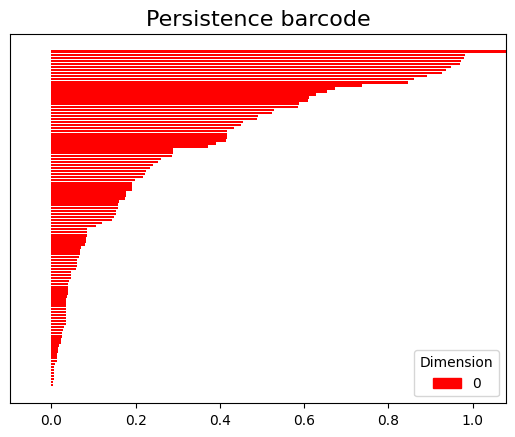

In [ ]:
'''
Build cluster filtration

Arguments: 
input_file: path to the input file
output_file: is the path where the output will be saved
embedding: anndata field of the embedding to use
resolutions: Resolution parameters
keys = Keys to save clusters in adata.obs
ground_truth: The ground truth field in adata.obs

Output: adata with clusters in adata.obs[keys[i]] for each resolution i
'''
#Build cluster filtration
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='jaccard')
pers = [p[1][1] for p in cluster_complex.persistence(min_persistence=-np.inf)]
pers[0] = 1
from gudhi import plot_persistence_barcode
from gudhi import SimplexTree
plot_persistence_barcode(cluster_complex.persistence(),colormap=((1,0,0),),alpha=1);
plt.savefig('/home/pbeamer/Documents/idc_persistence_barcode.png',dpi=300)


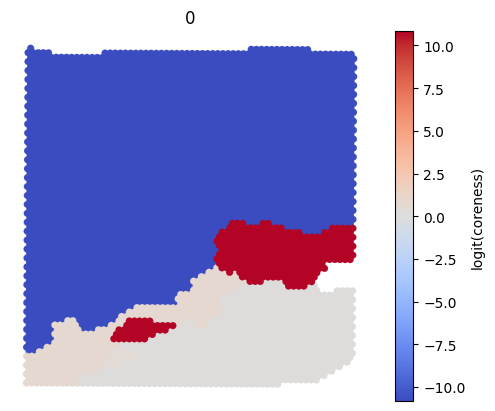

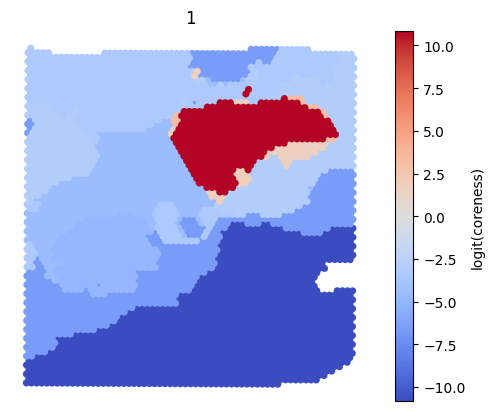

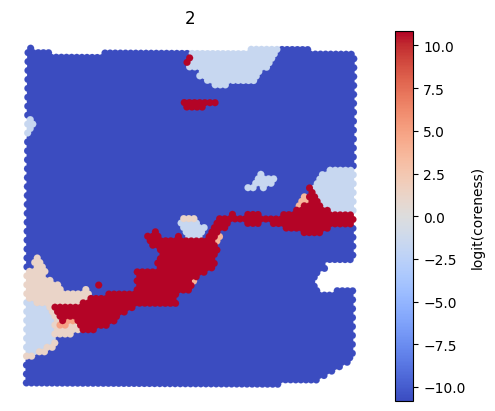

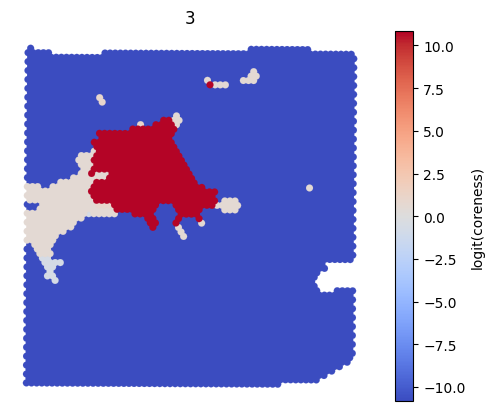

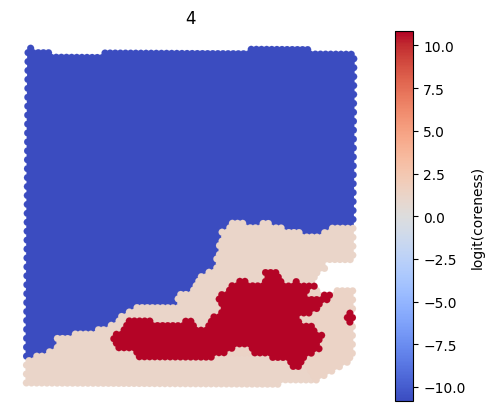

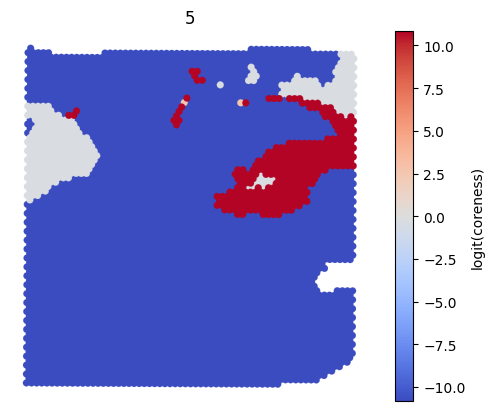

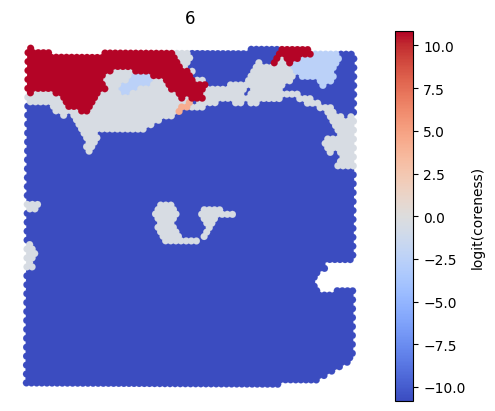

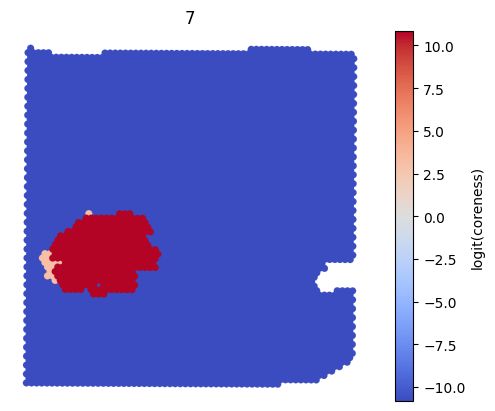

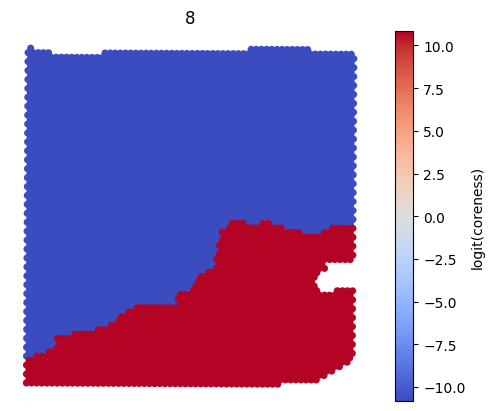

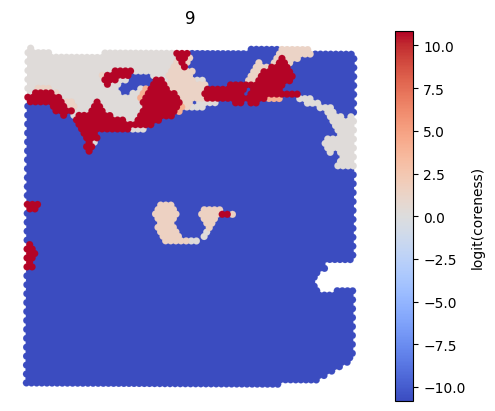

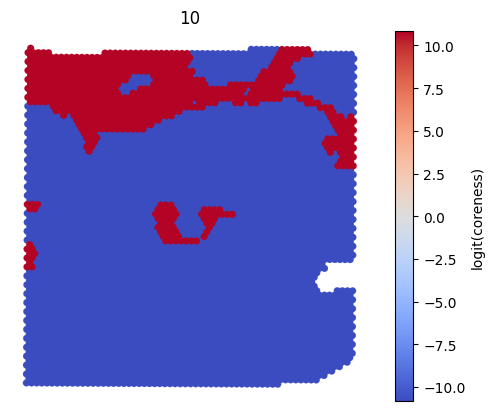

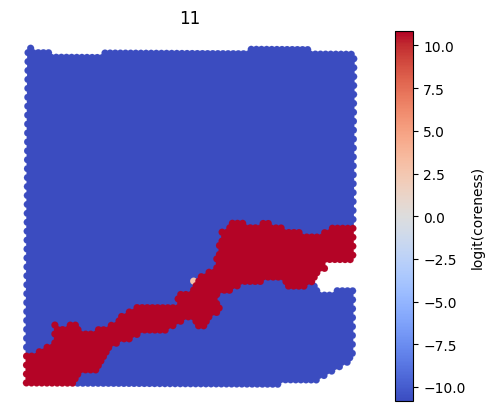

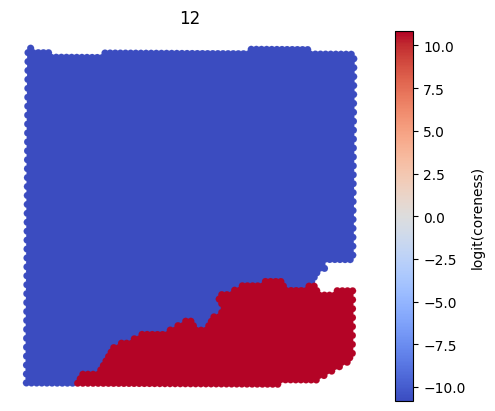

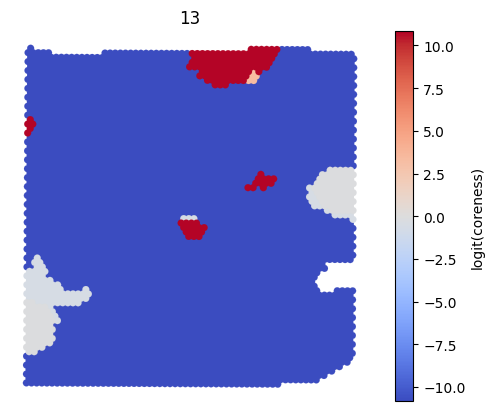

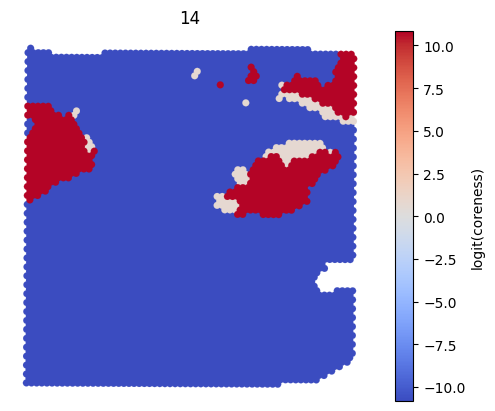

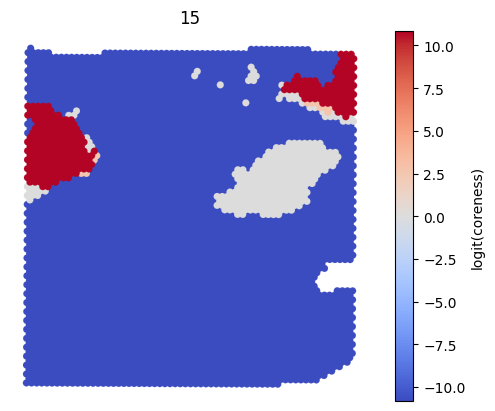

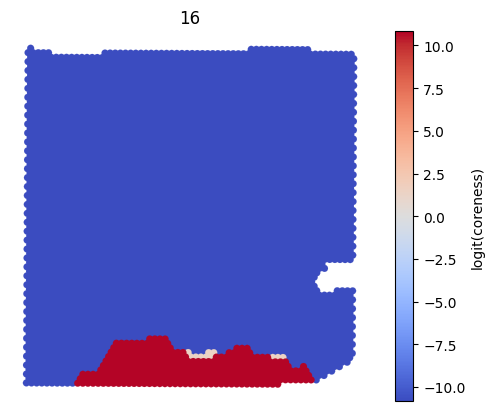

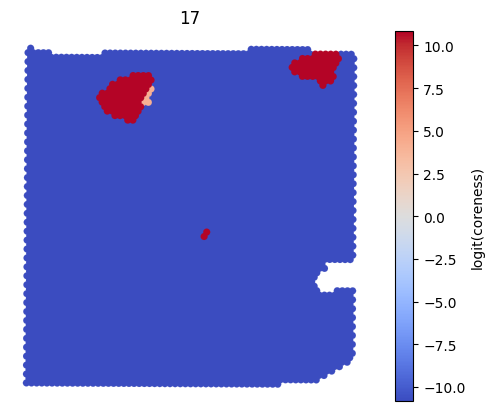

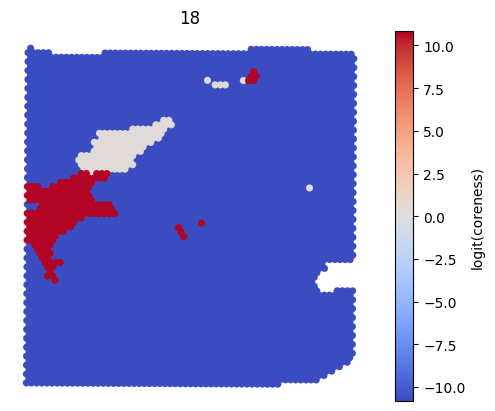

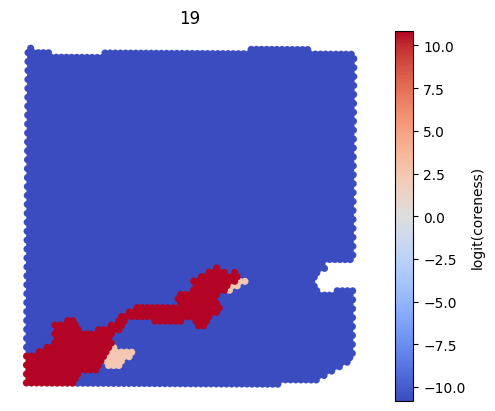

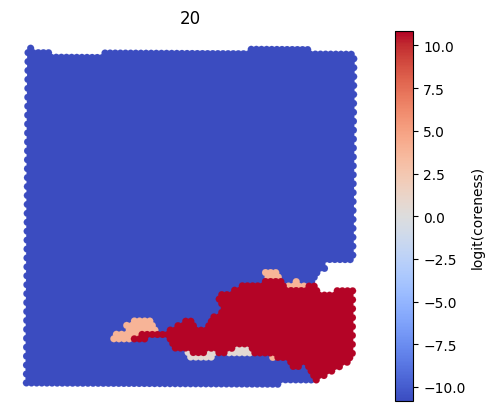

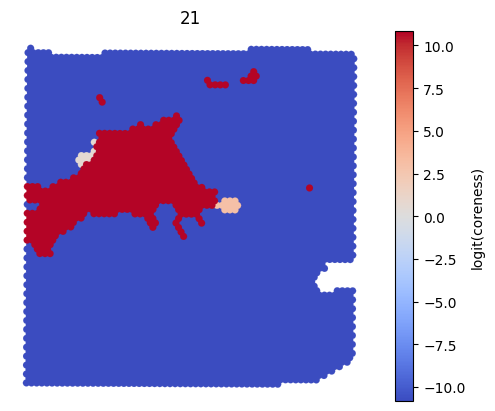

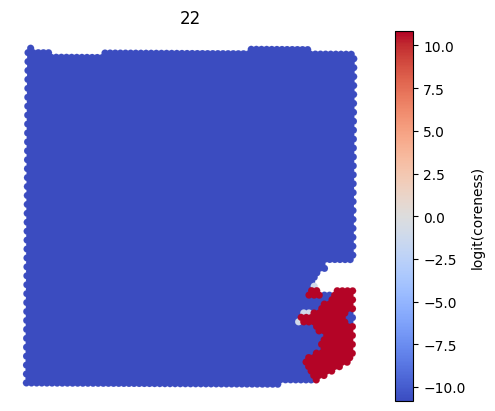

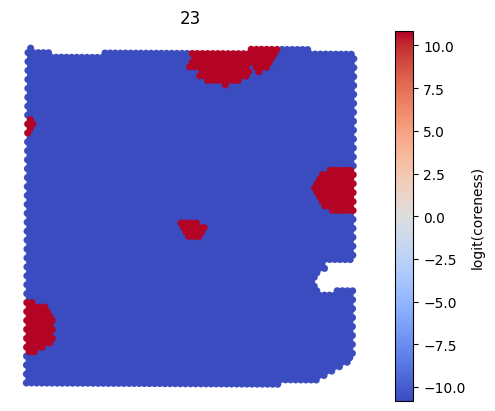

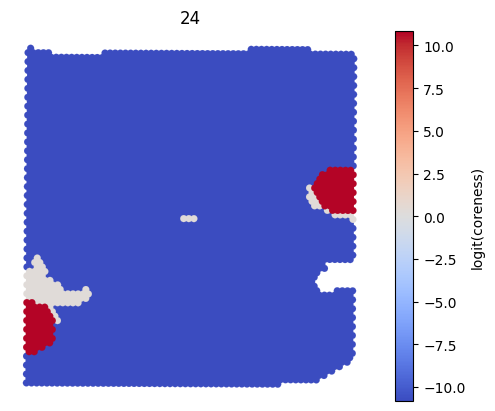

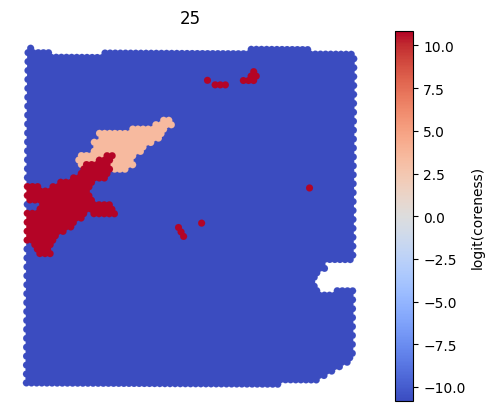

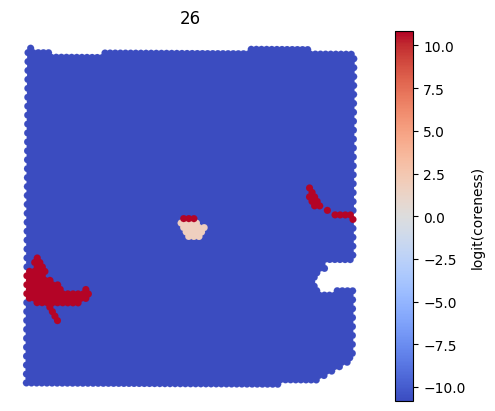

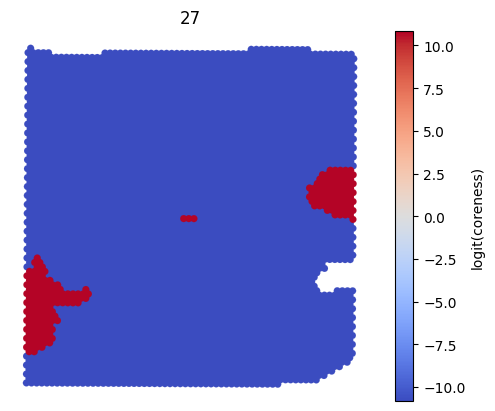

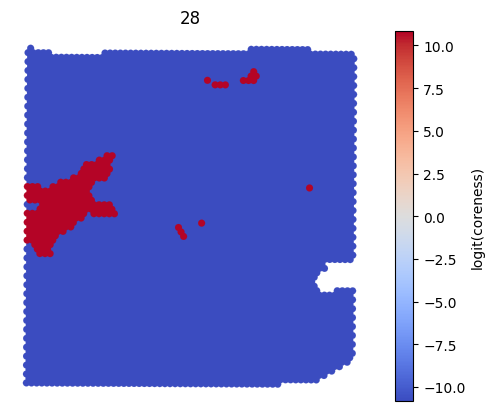

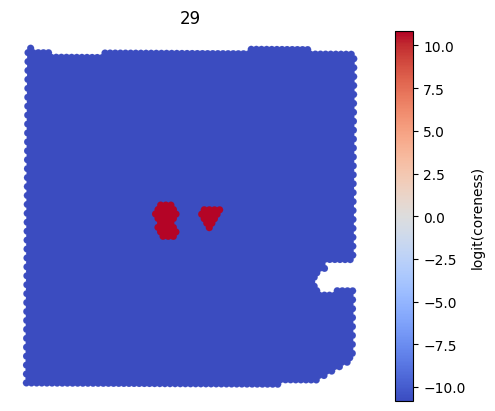

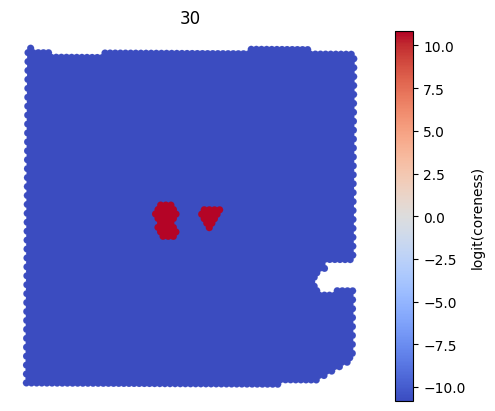

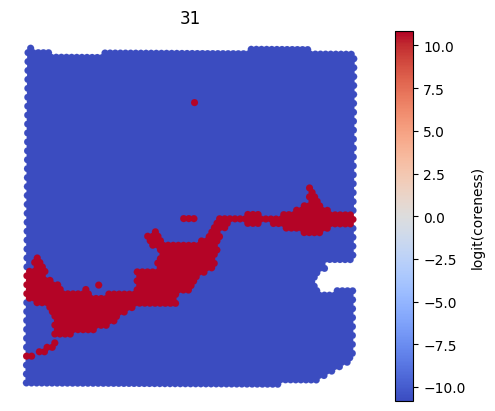

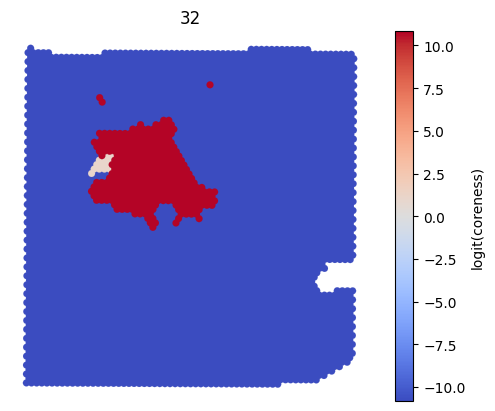

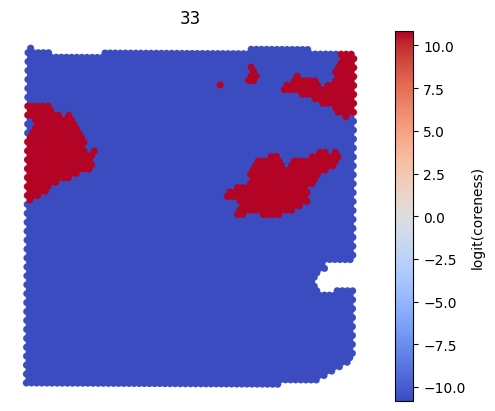

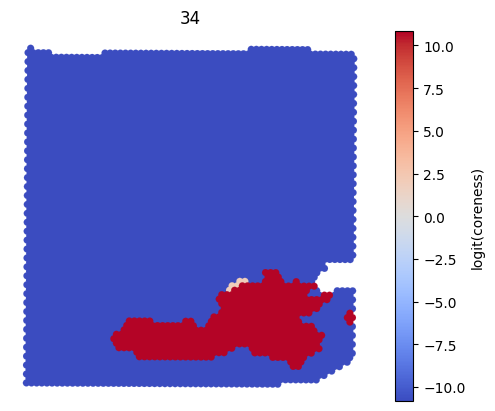

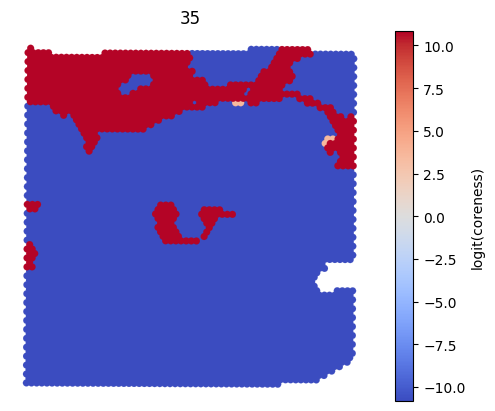

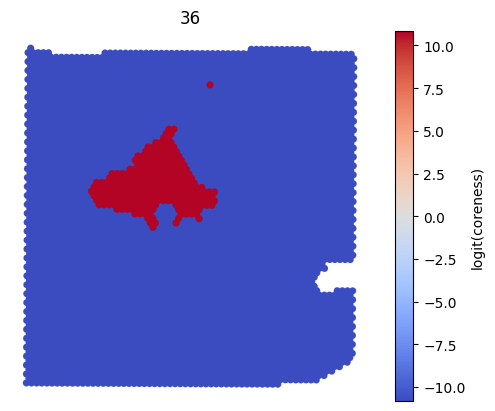

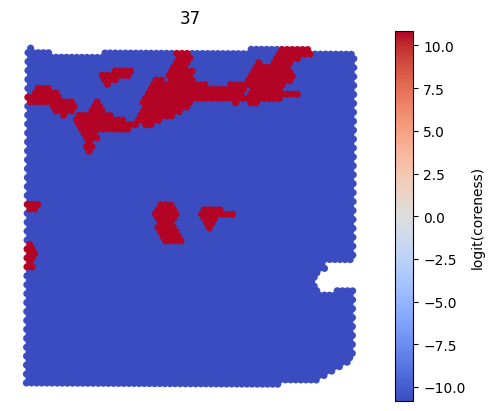

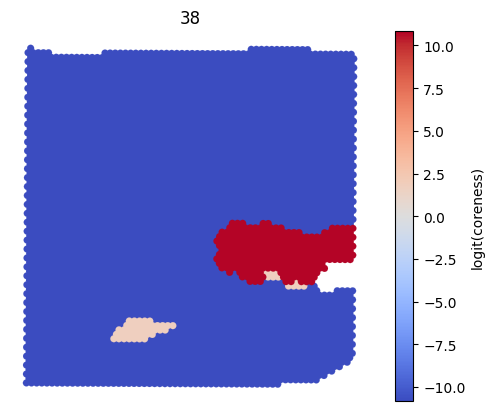

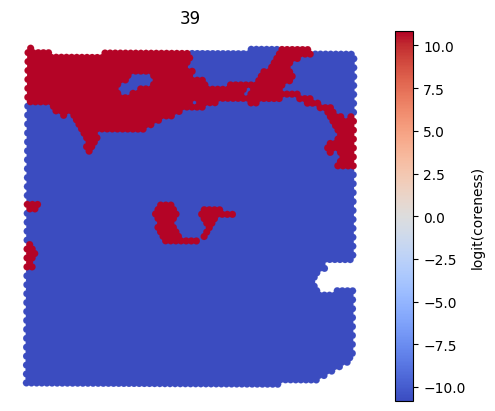

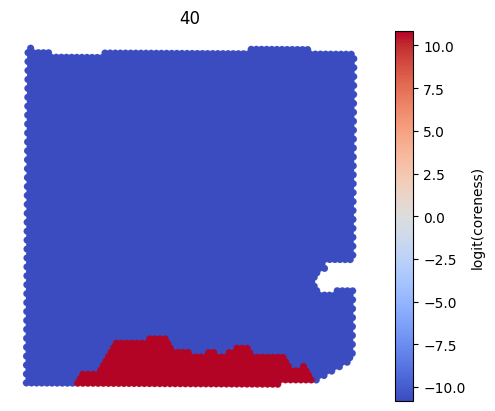

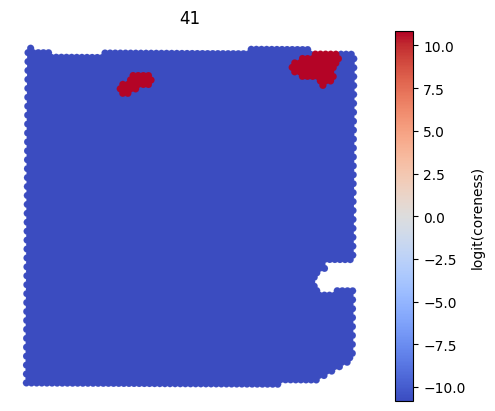

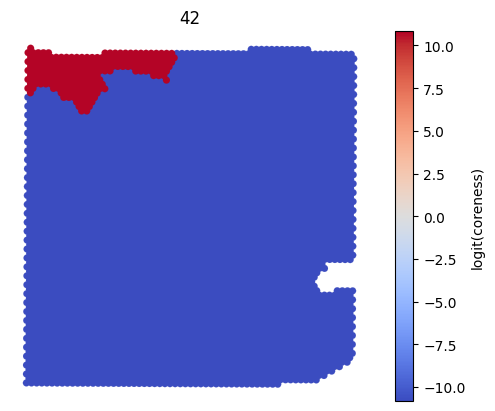

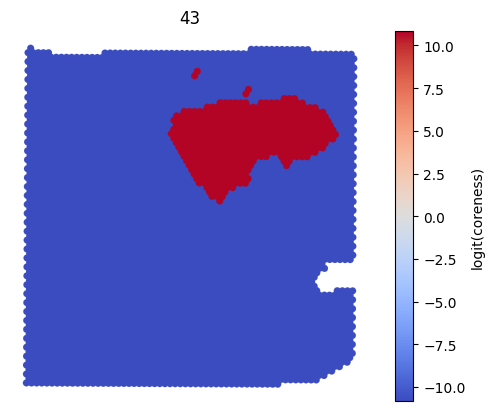

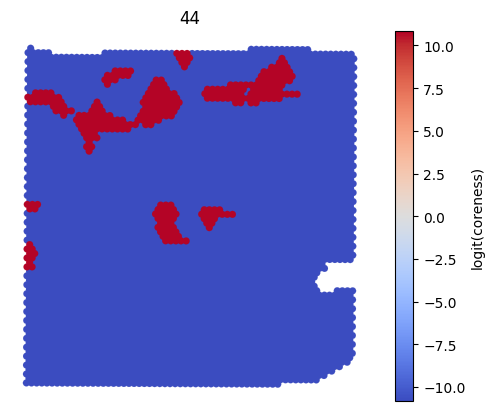

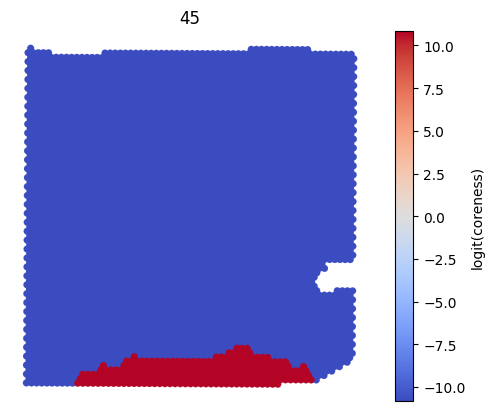

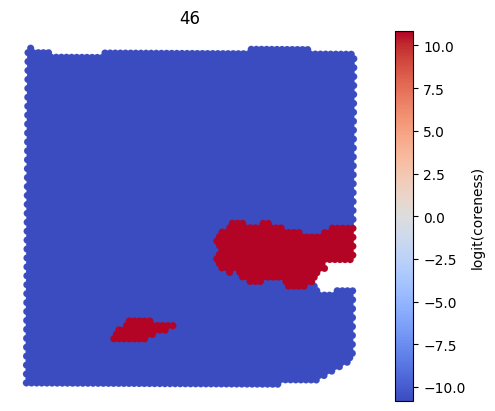

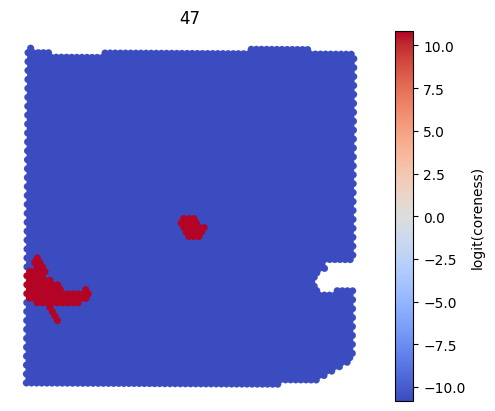

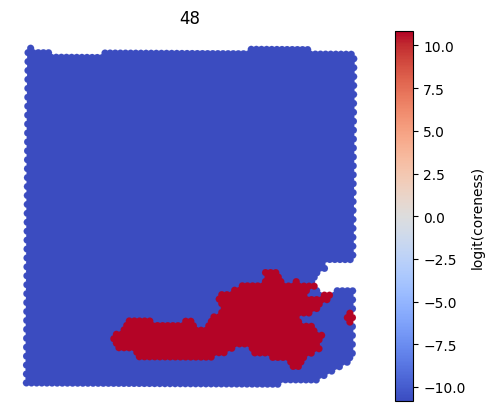

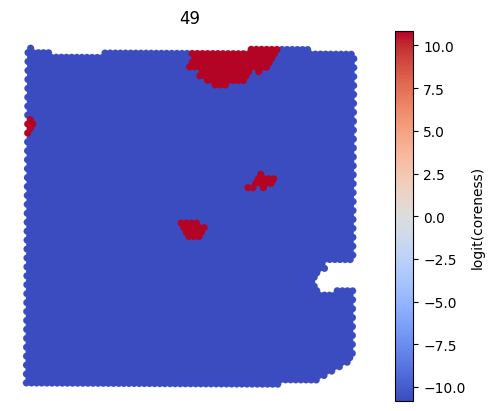

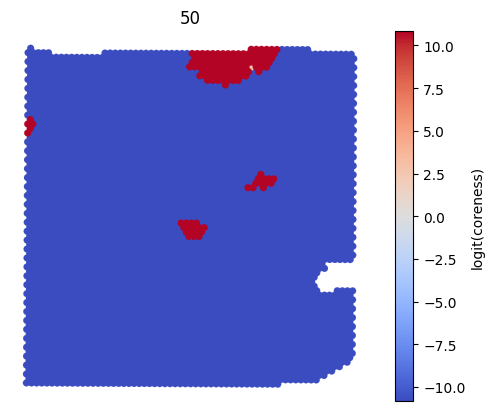

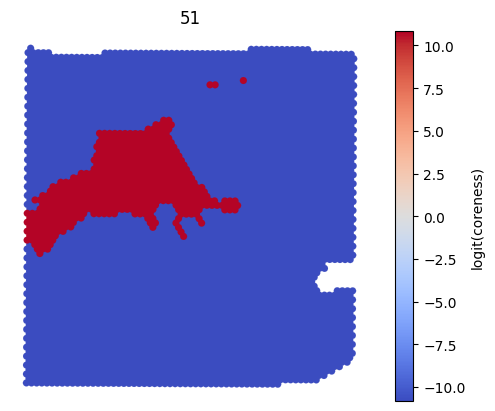

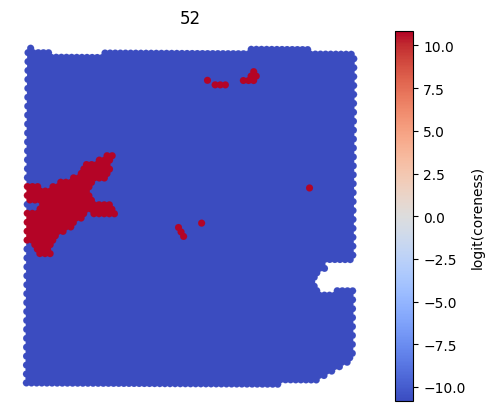

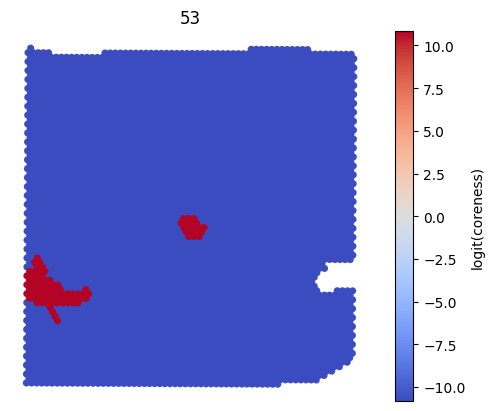

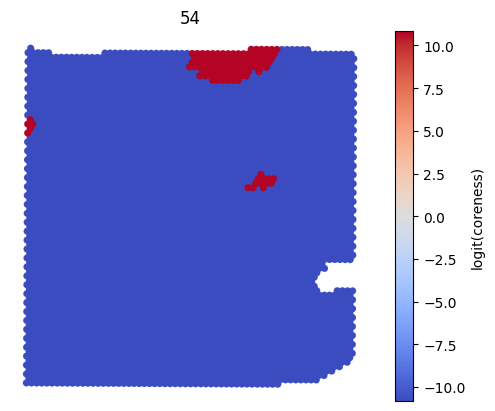

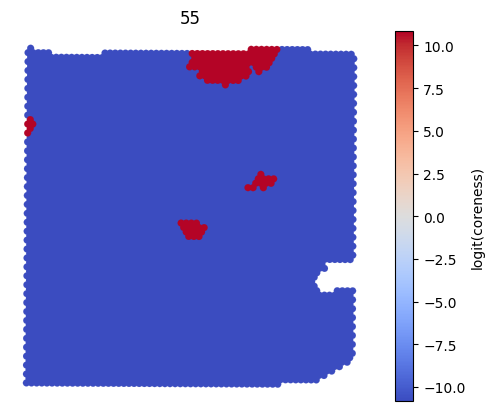

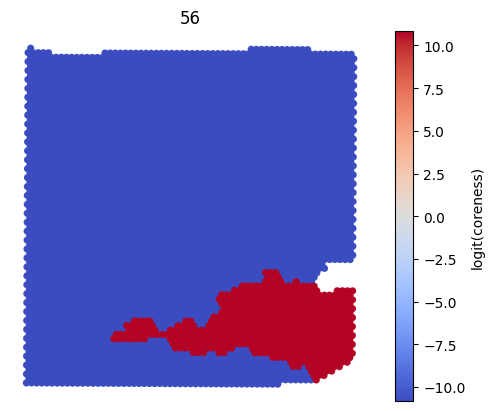

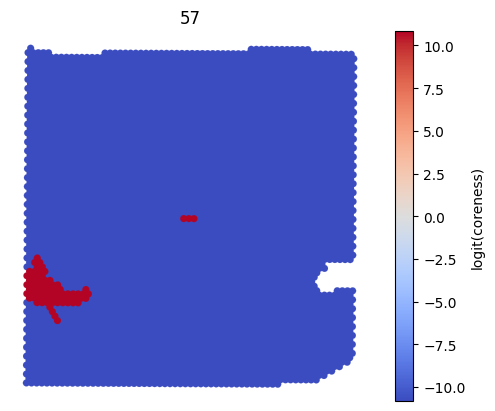

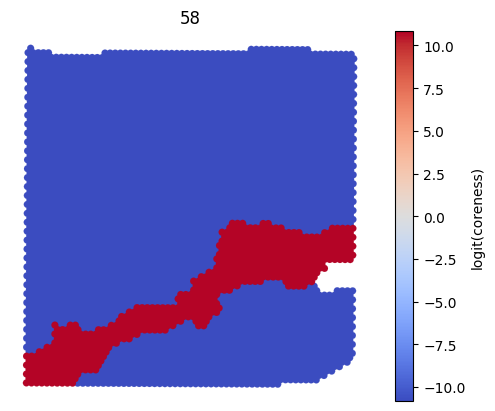

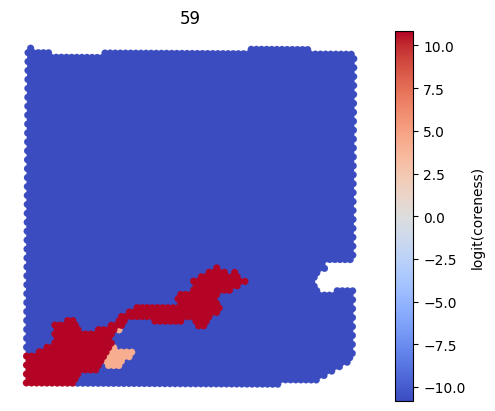

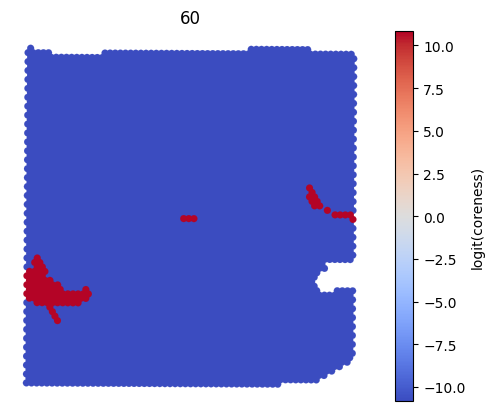

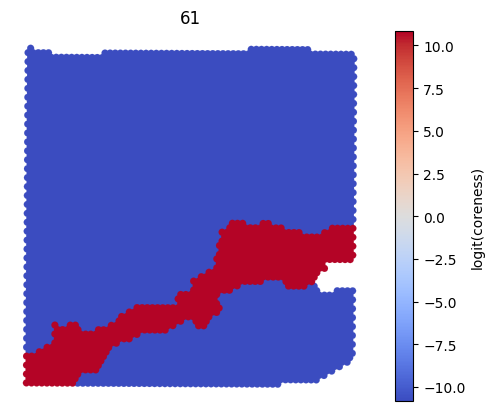

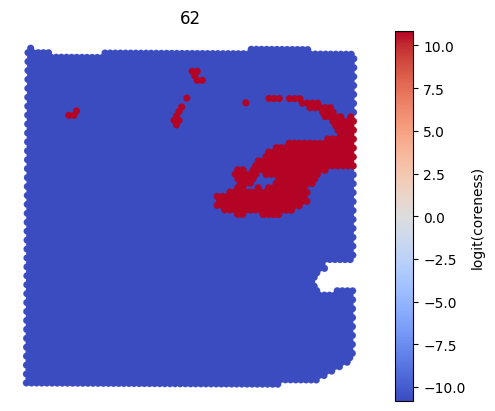

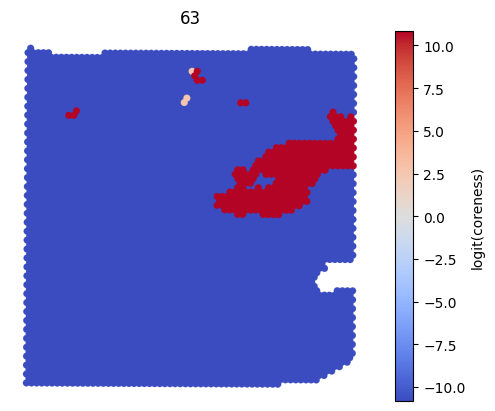

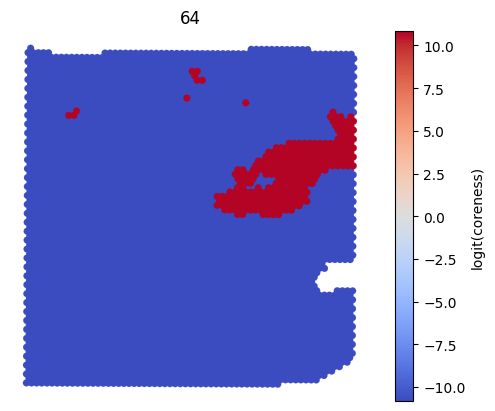

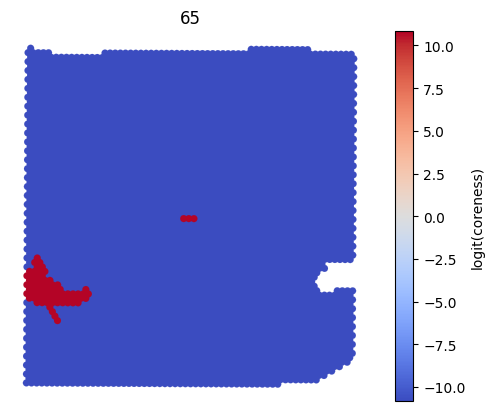

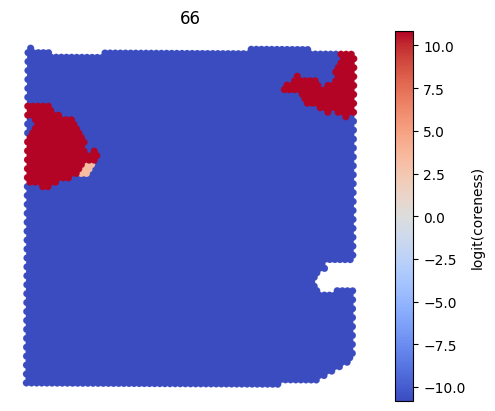

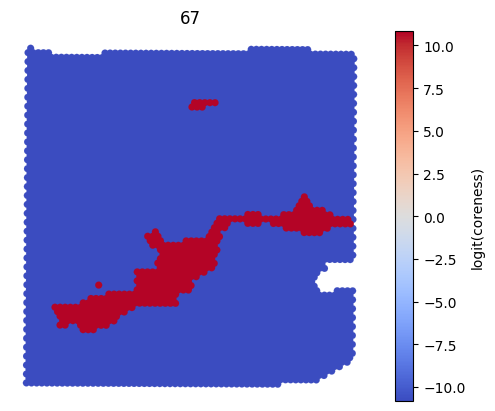

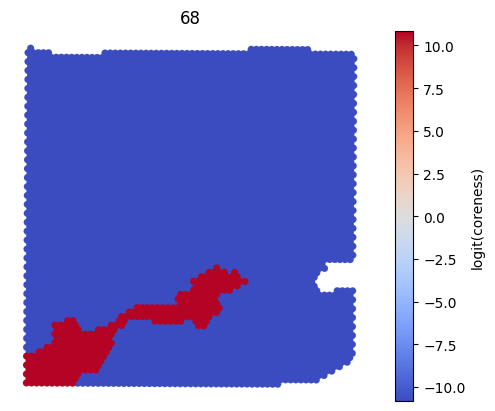

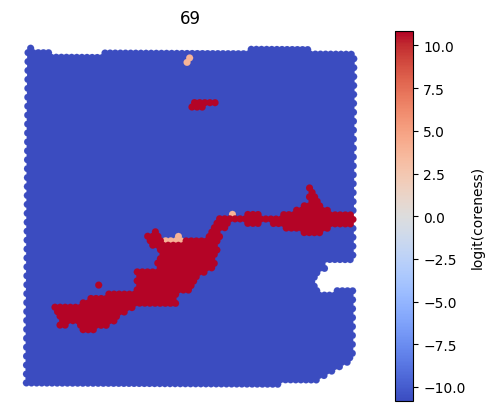

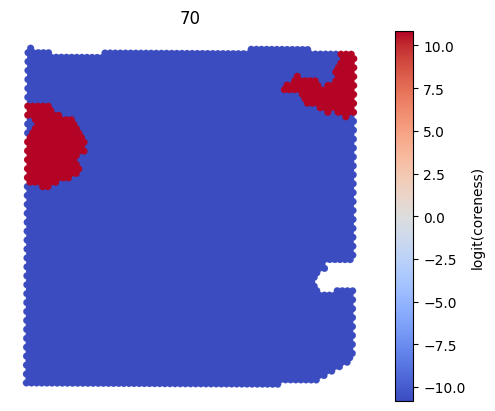

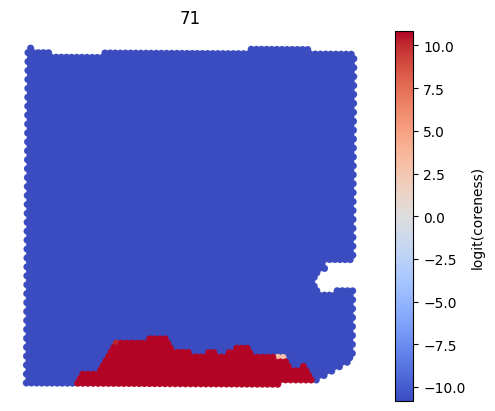

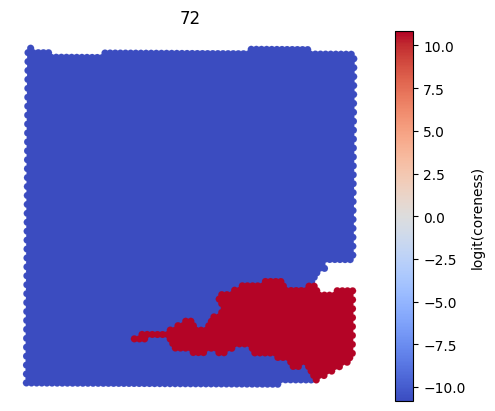

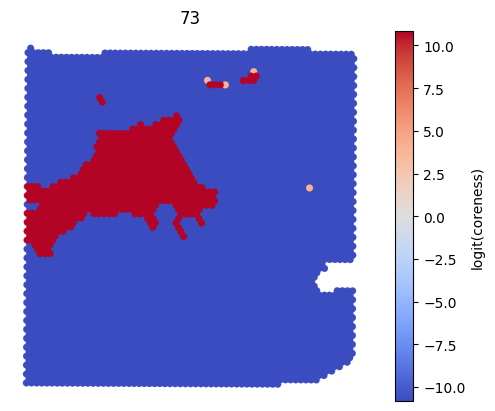

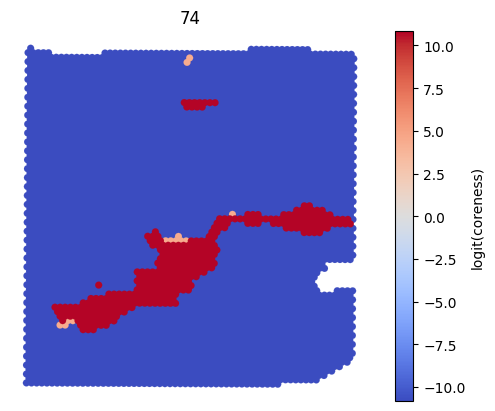

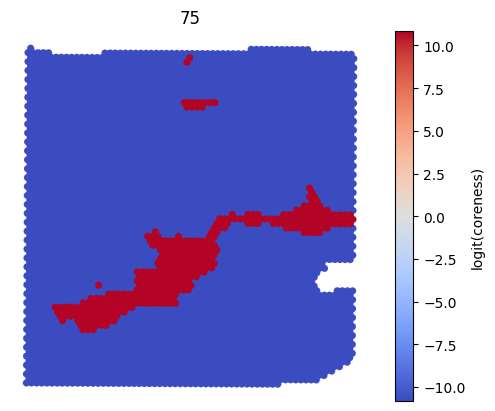

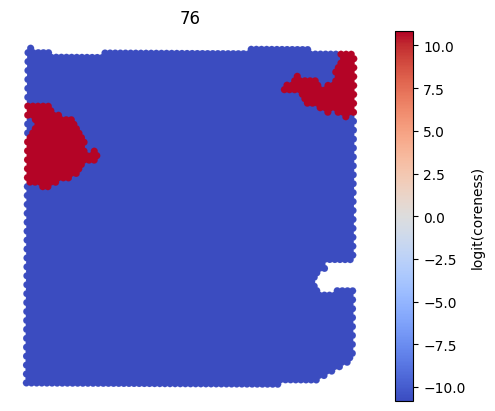

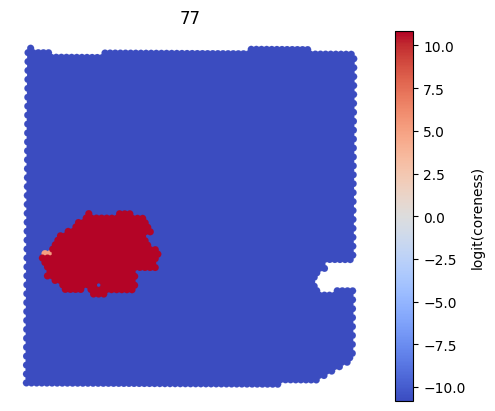

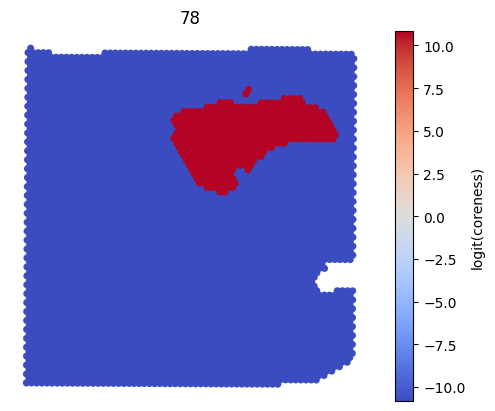

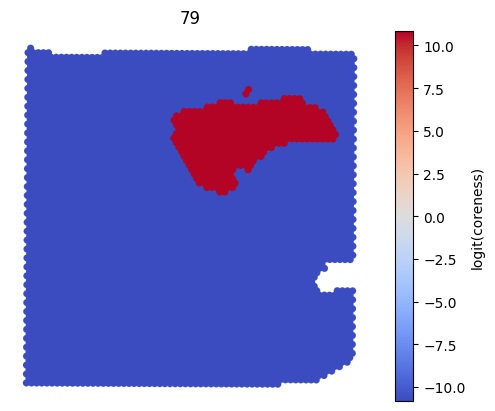

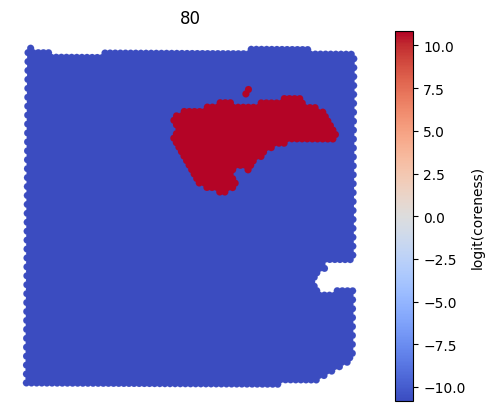

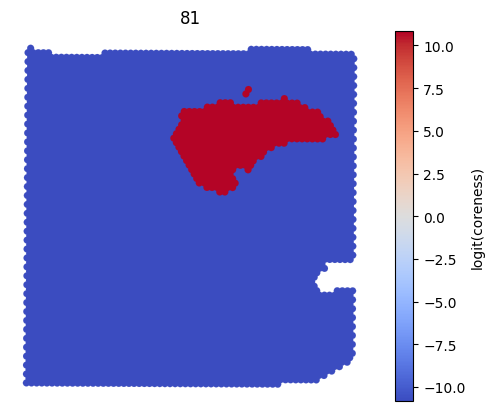

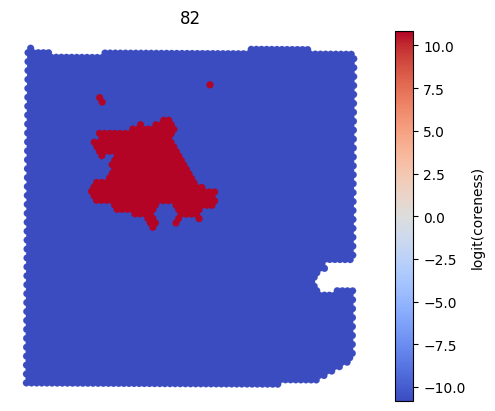

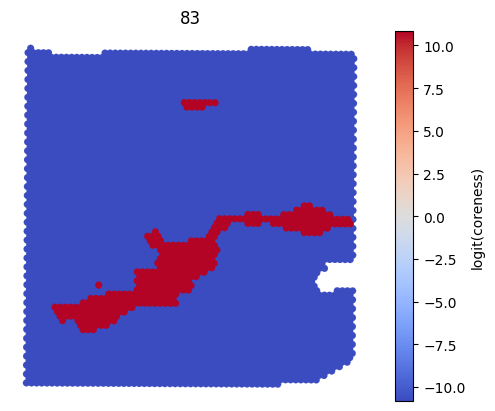

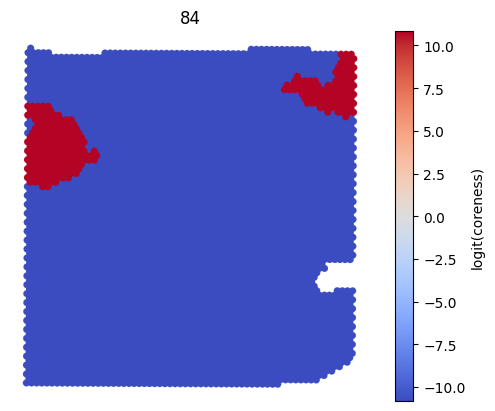

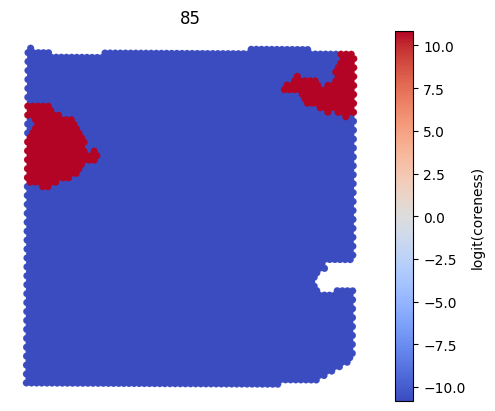

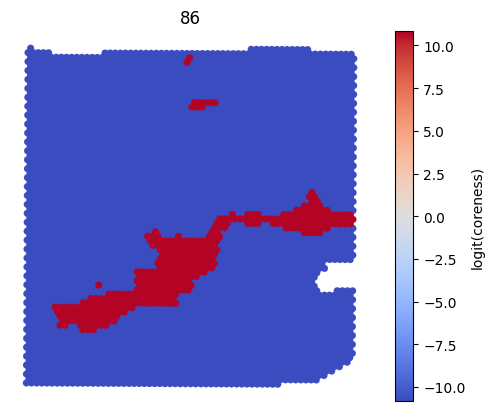

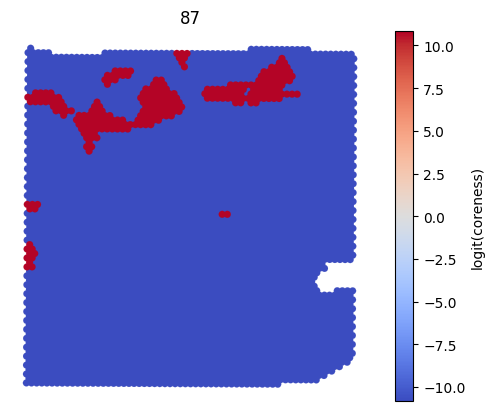

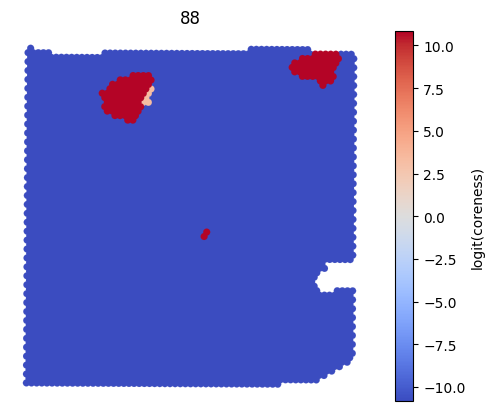

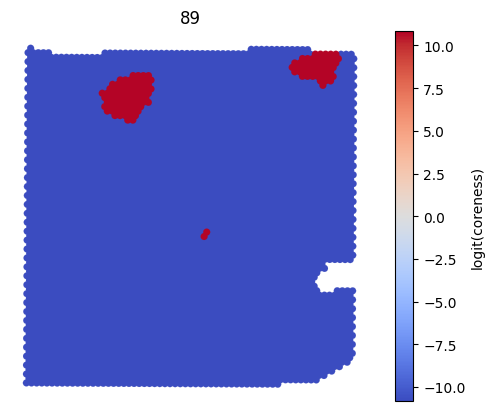

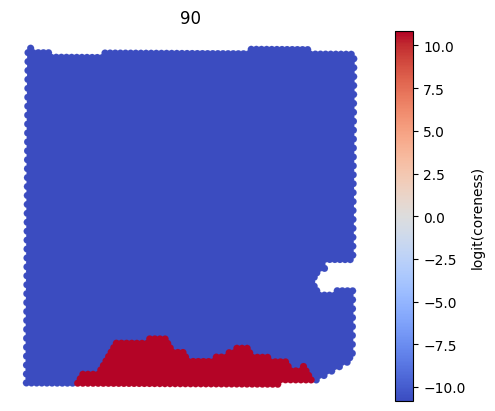

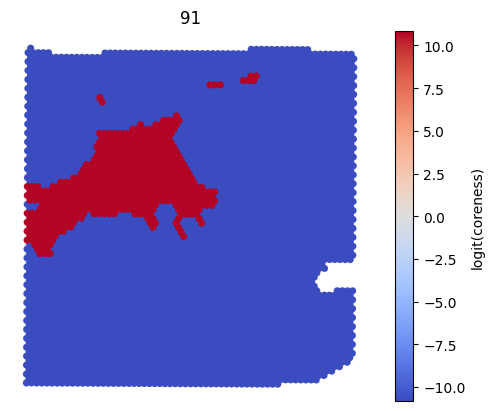

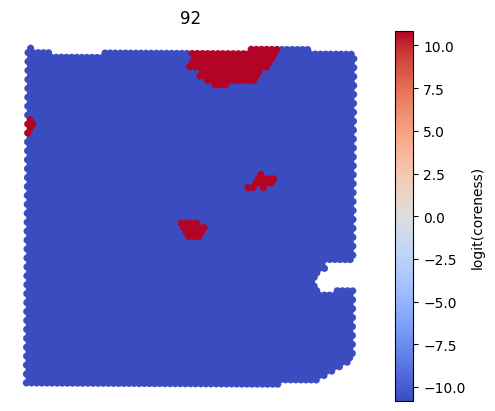

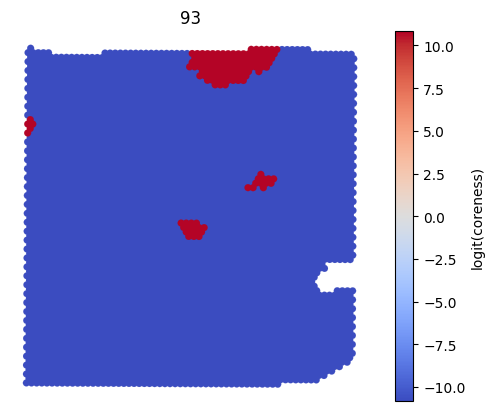

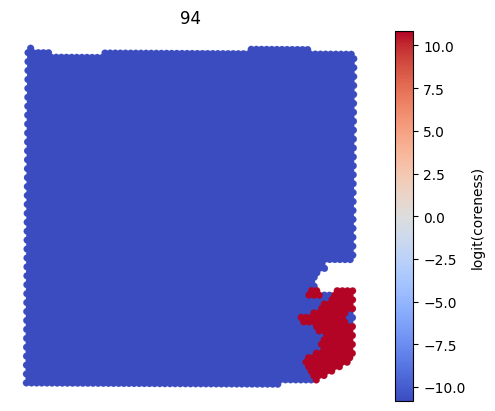

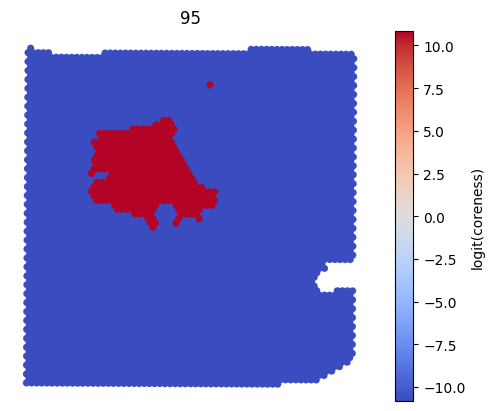

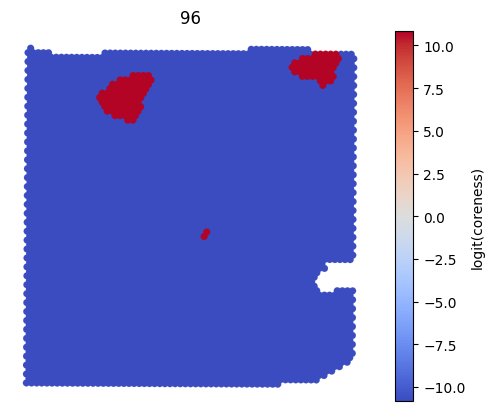

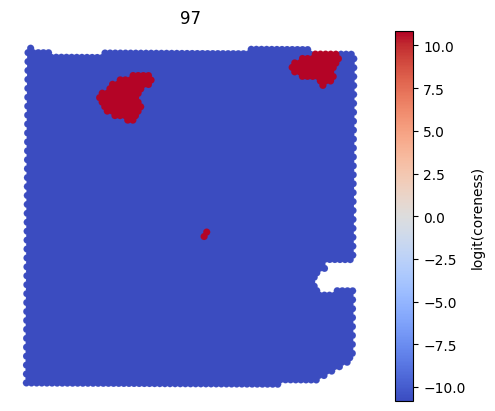

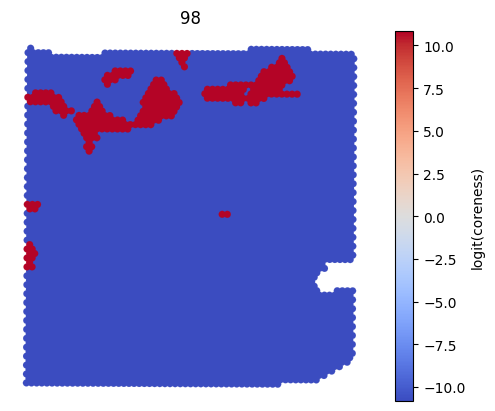

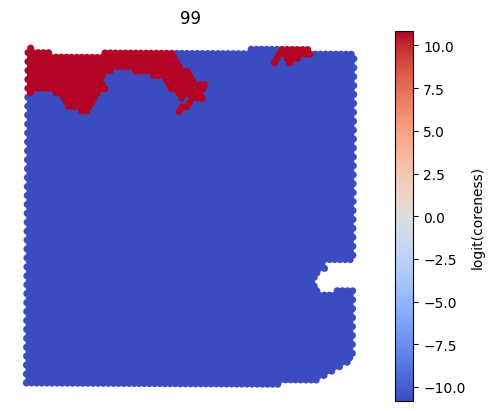

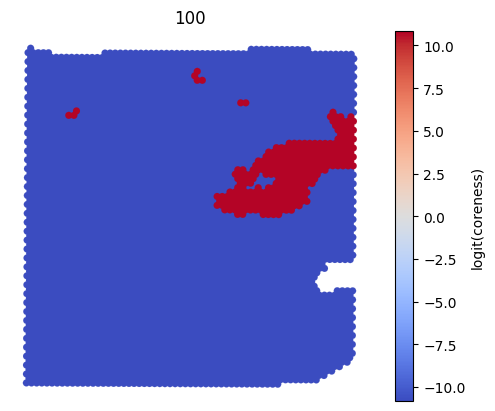

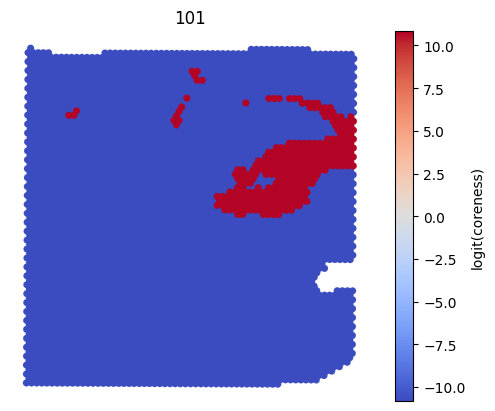

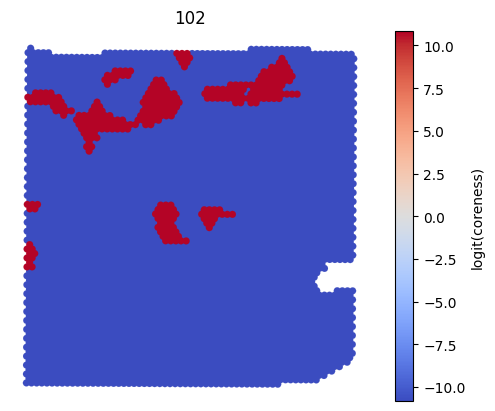

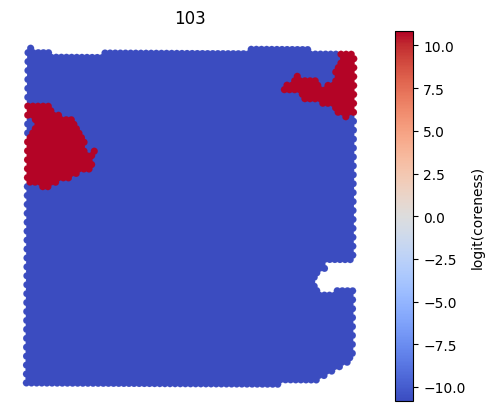

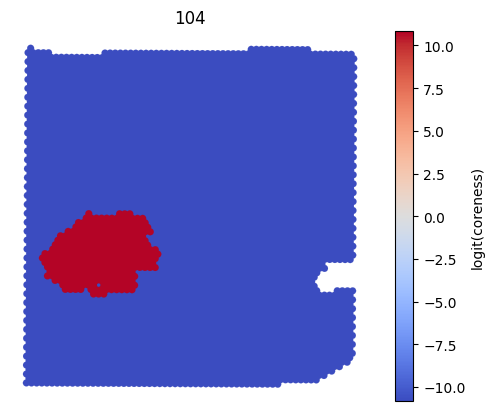

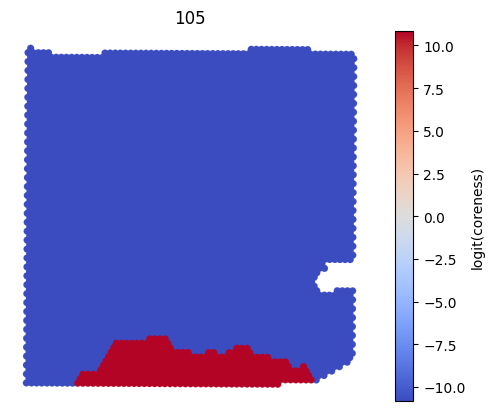

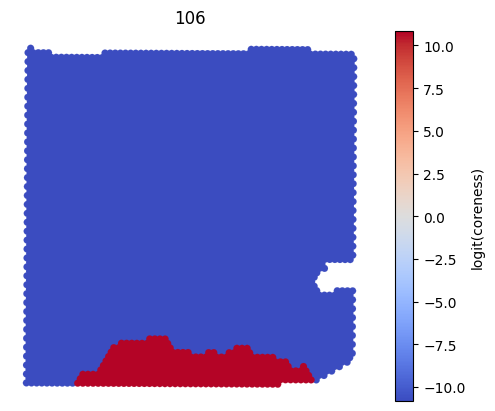

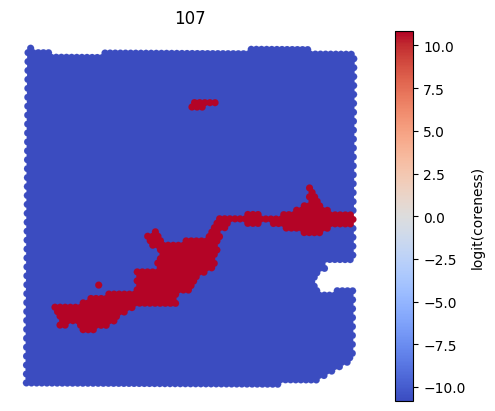

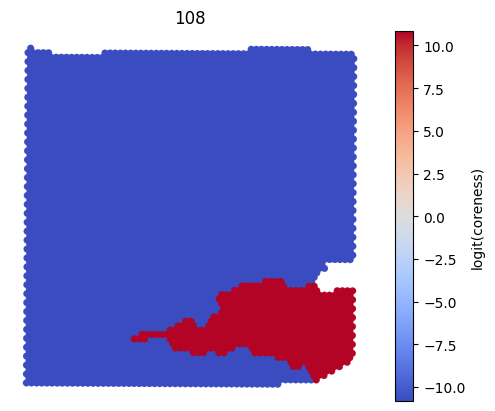

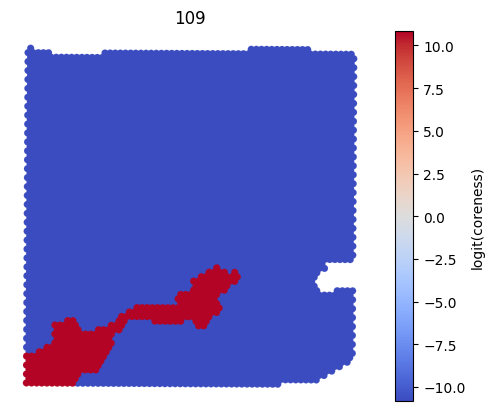

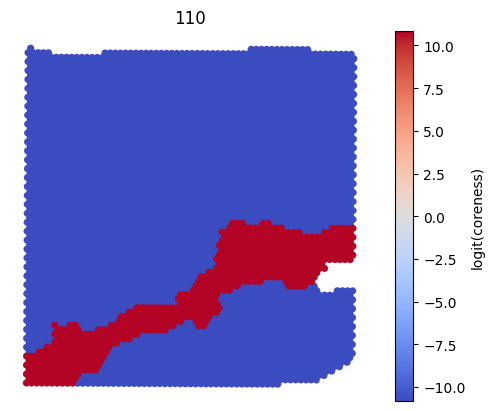

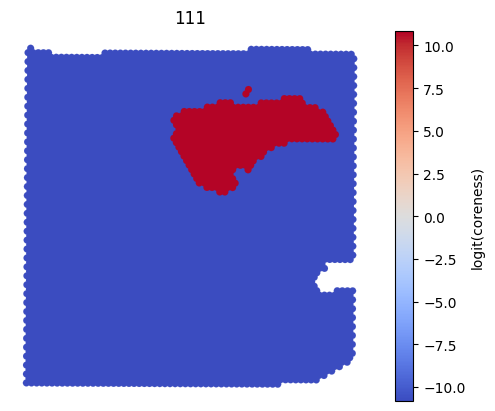

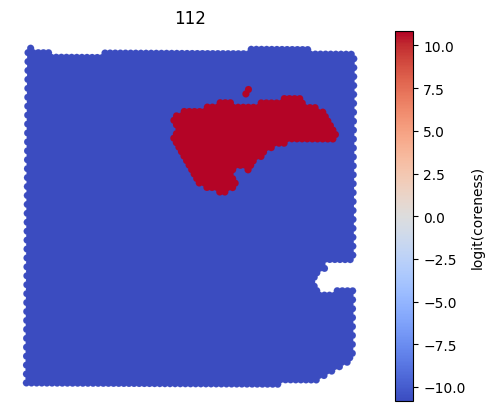

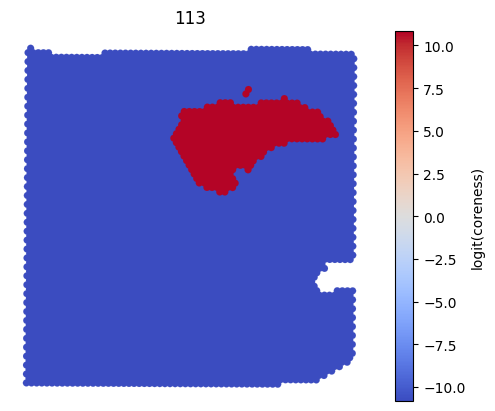

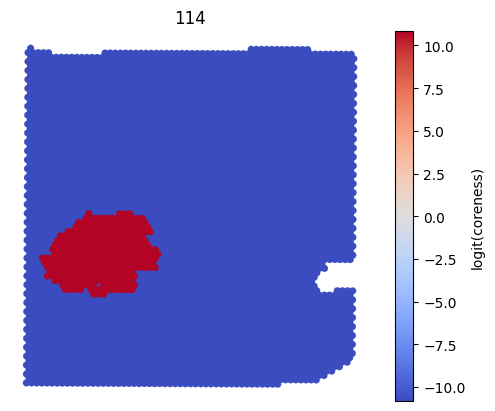

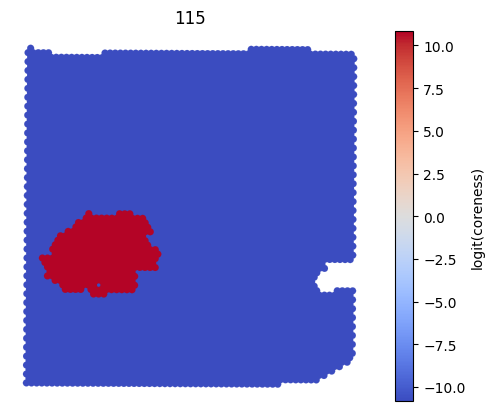

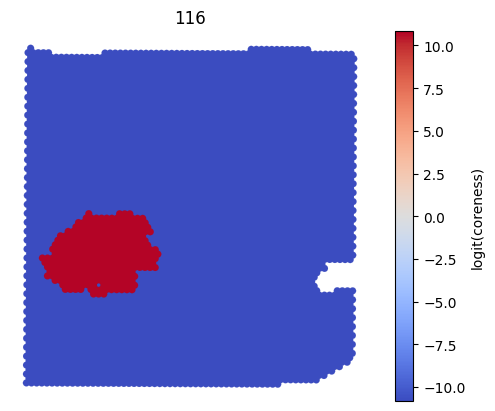

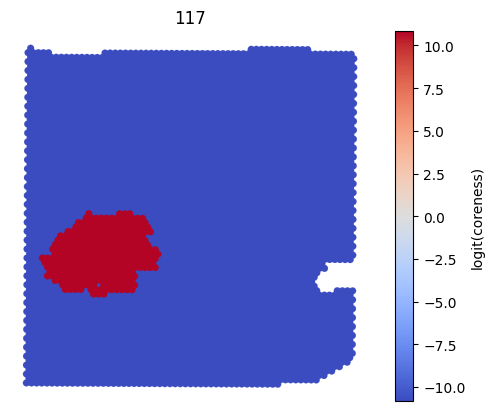

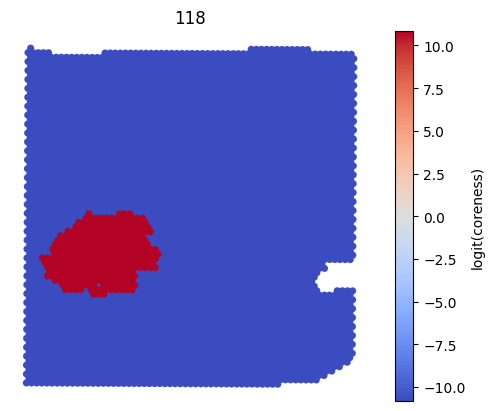

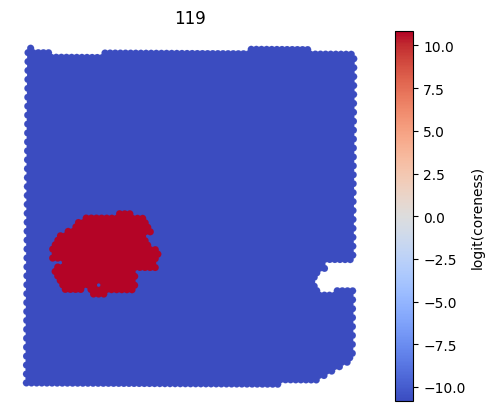

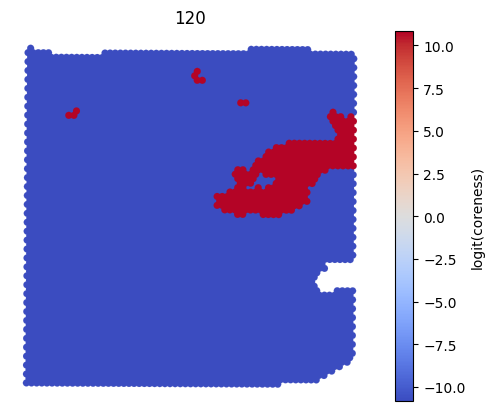

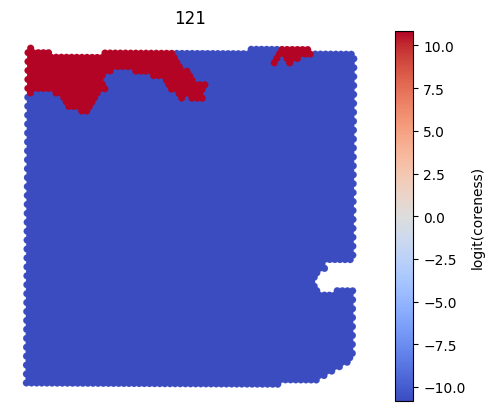

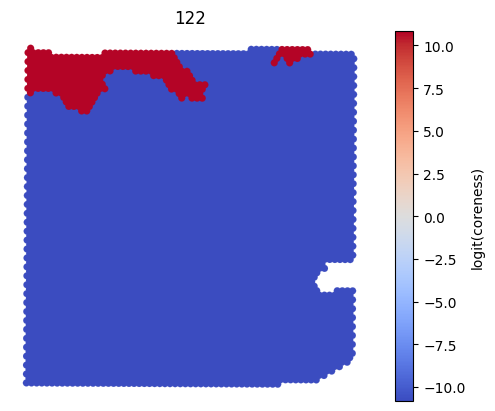

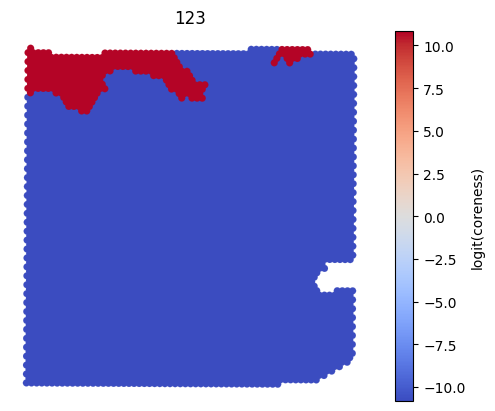

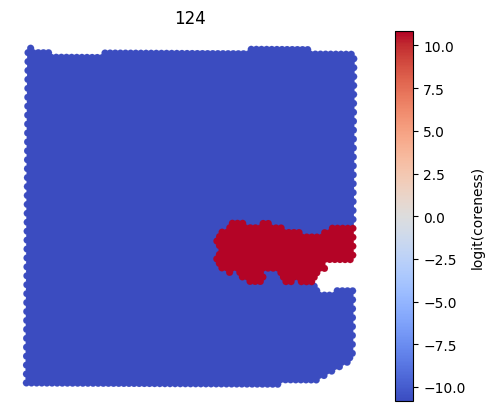

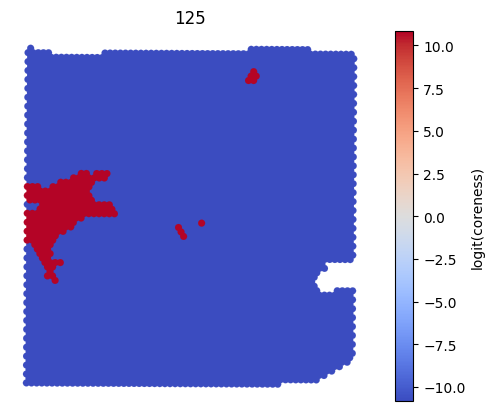

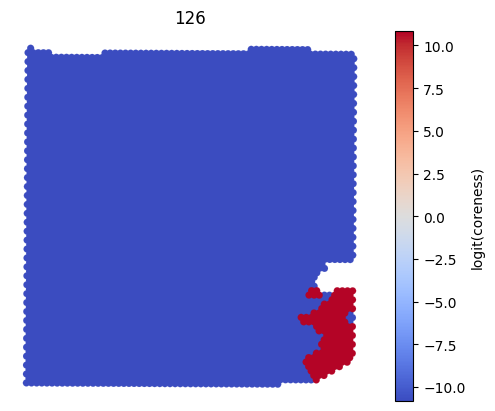

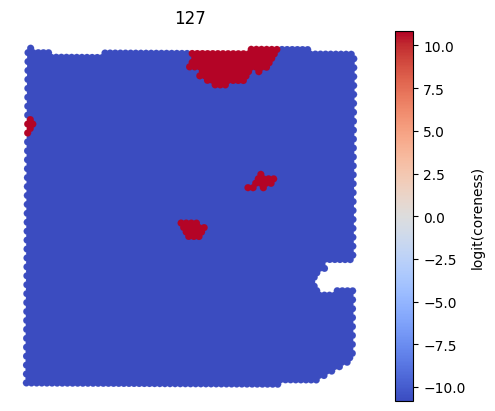

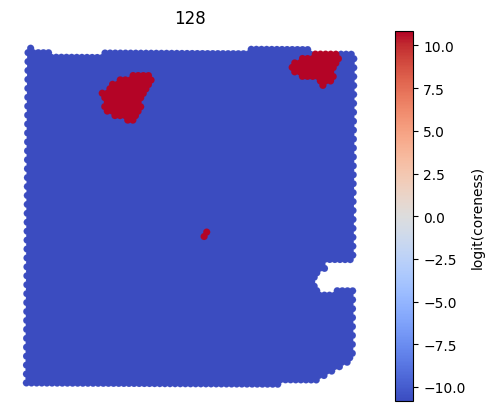

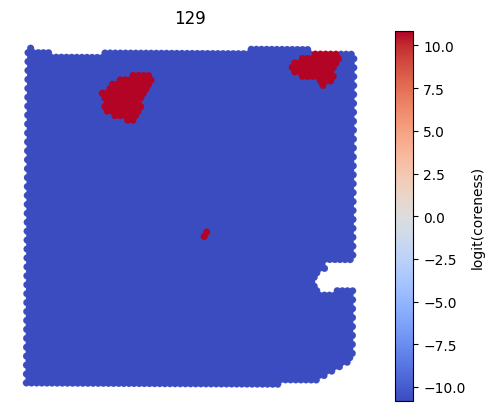

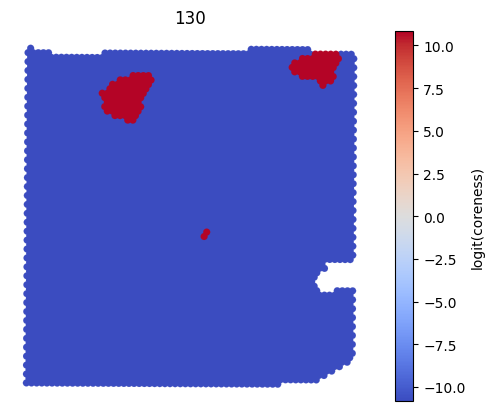

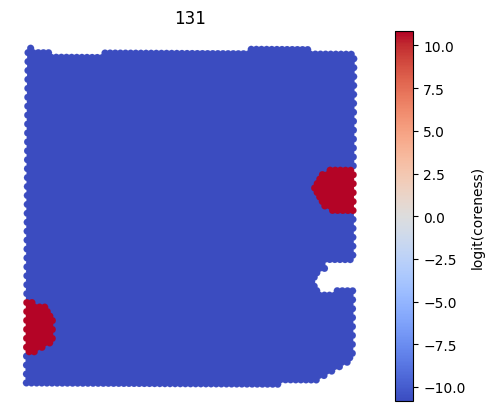

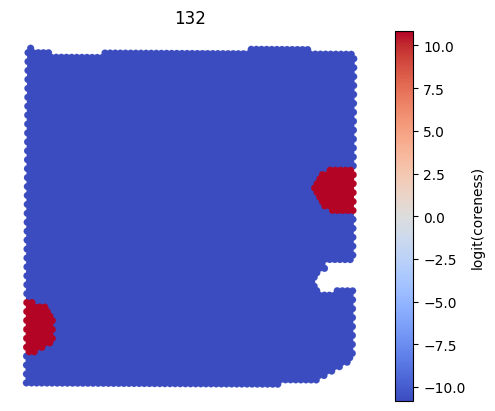

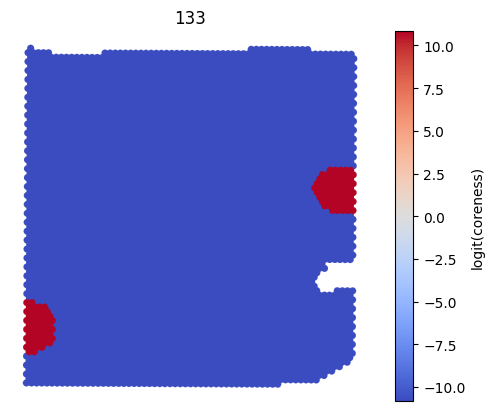

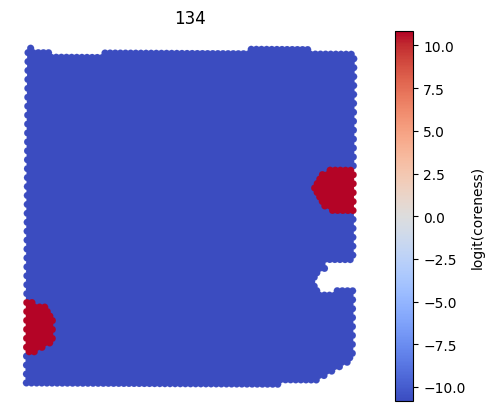

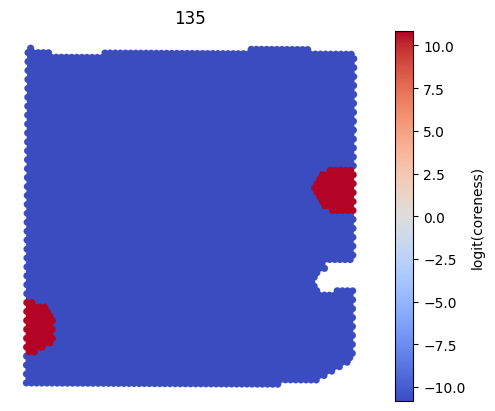

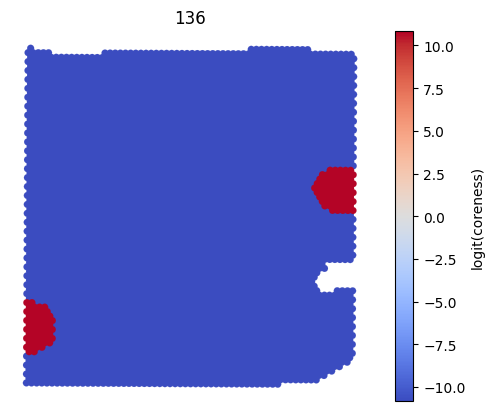

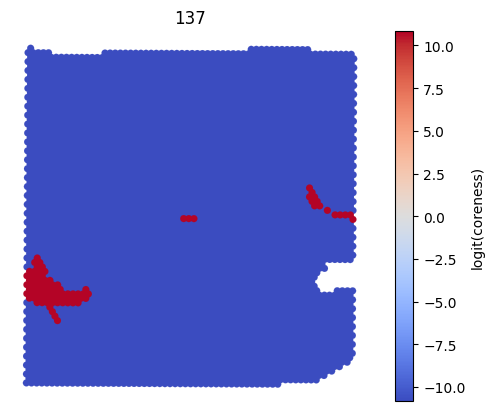

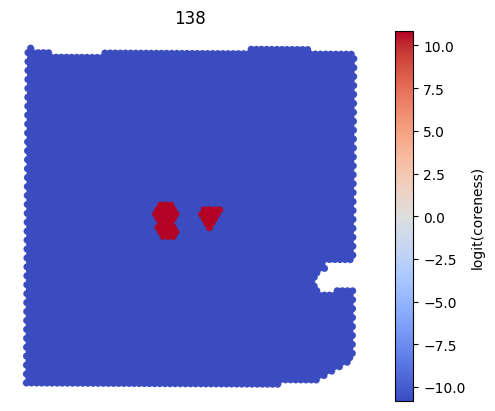

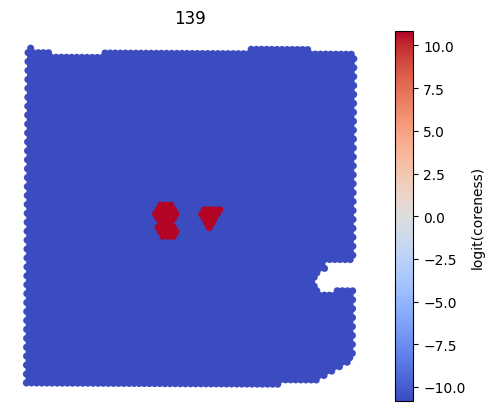

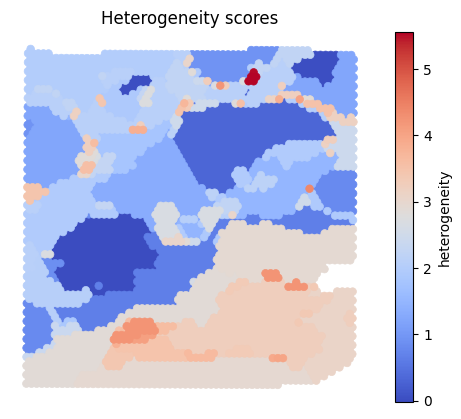

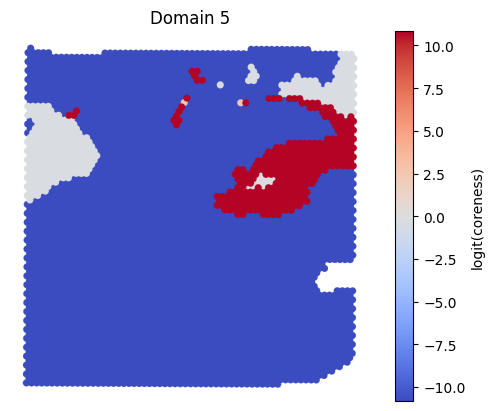

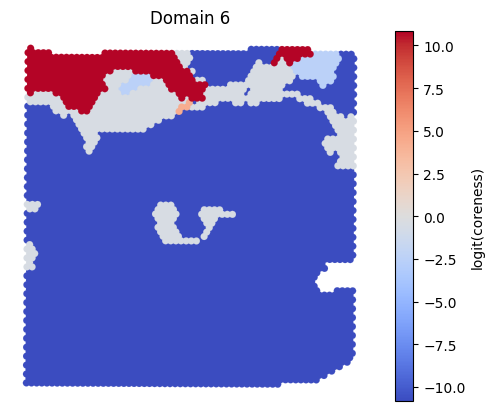

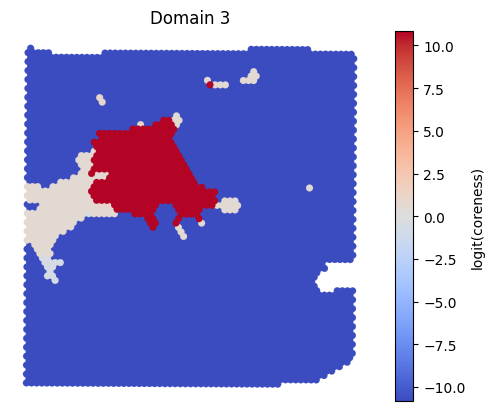

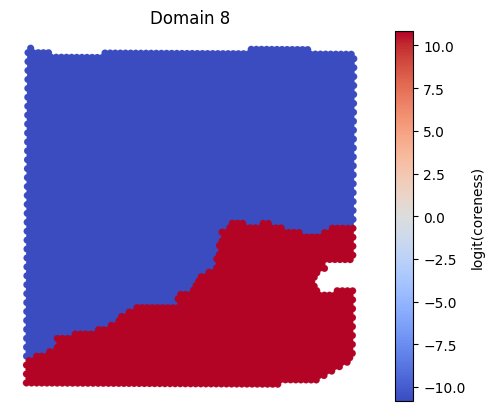

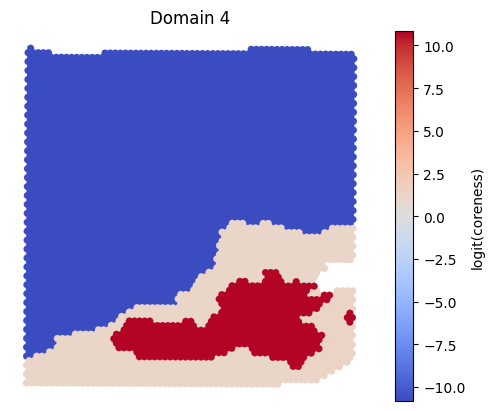

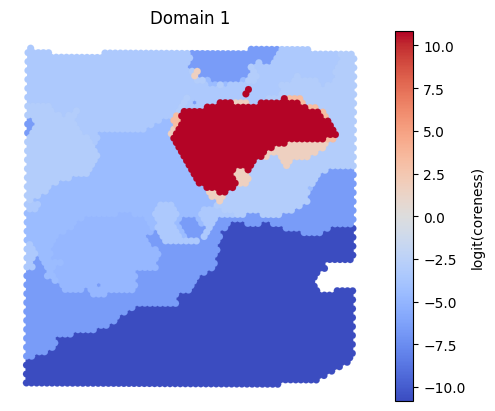

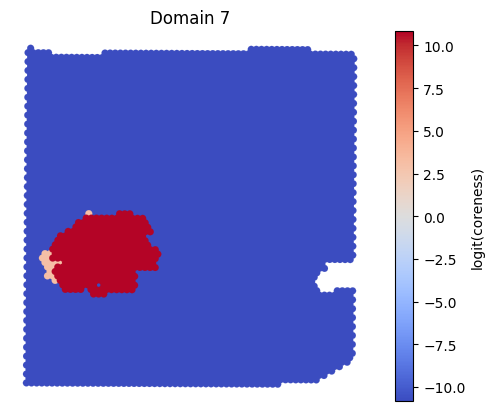

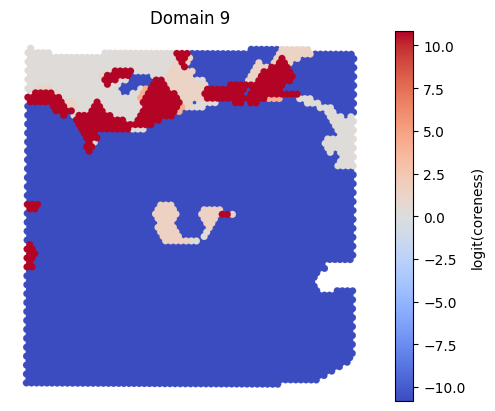

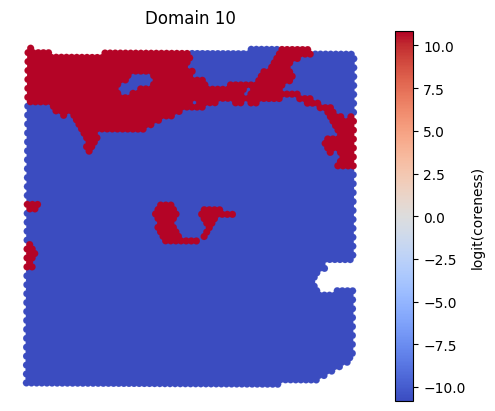

In [5]:

'''
Generate and map multiscale domains

Arguments:
spatial: spatial coordinates of points
cluster_complex: gudhi simplex tree of cluster filtration
clusterings: list of clusters at each resolution, containing cell indices
num_domains: number of multiscale domains to map, if 0 then all domains
filt: filter out persistent clusters with persistence less than this value
order: order of the output,'size' or default 'persistence'
redundant_filter: filter out domains which are to similar to previously examined domains, default is False
plots: 'on' to plot the domains

Output:
list of multiscale domains, consisting of coreness score for each point
'''
#Generate multiscale domains

adata.obsm['multiscale'] = phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='size-persistence',plots='on')
tumor_domains = [5,6,3,8,4,1,7,9,10]
for i in tumor_domains:
    phd_ms.tl.plot_multiscale(adata.obsm['multiscale'][:,i],adata.obsm['spatial'],title='Domain '+str(i))

[[ 7.]
 [11.]
 [ 4.]
 ...
 [ 4.]
 [ 4.]
 [11.]]


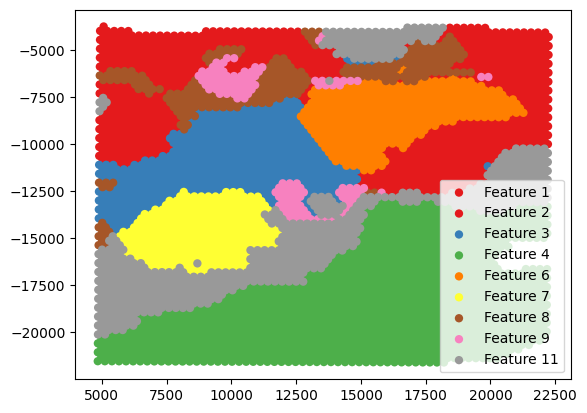

In [6]:
#Differential gene expression analysis
import pandas as pd


    
#plot the diff expressed genes
adata.obs['tumor_cat'] = phd_ms.tl.construct_clustering(adata,tumor_domains,pers)

0.980974917927146
View of AnnData object with n_obs × n_vars = 4727 × 6
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'clusters0.05', 'clusters0.15555555555555556', 'clusters0.2611111111111111', 'clusters0.36666666666666664', 'clusters0.4722222222222222', 'clusters0.5777777777777778', 'clusters0.6833333333333333', 'clusters0.788888888888889', 'clusters0.8944444444444445', 'clusters1.0', 'clusters0.15', 'clusters0.25', 'clusters0.35', 'clusters0.44999999999999996', 'clusters0.5499999999999999', 'clusters0.65', 'clusters0.75', 'clusters0.85', 'clusters0.95', 'clusters0.2033333333333333', 'clusters0.25666666666666665', 'clusters0.30999999999999994', 'clusters0.3633333333333333', 'clusters0.41666666666666

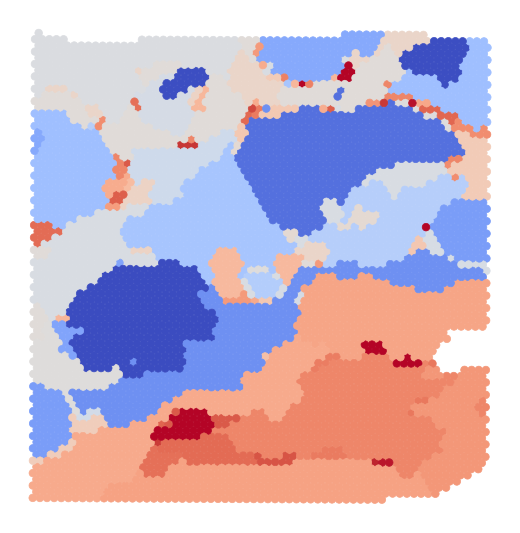

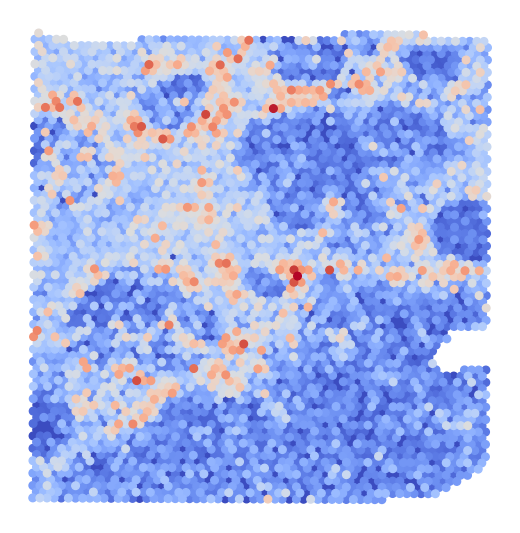

In [7]:

heterogeneity = adata.obsm['multiscale']@ np.array(pers)
print(np.min(heterogeneity))
heterogeneity = [cc if cc<np.quantile(heterogeneity,0.99) else np.quantile(heterogeneity,0.99) for cc in heterogeneity]
plt.figure(figsize=(8, 20/3))
a = plt.gca()
a.set_aspect('equal')
plt.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1],c=heterogeneity,cmap='coolwarm',s=30,linewidths=.5)
#cbar = plt.colorbar()
a.axis('off')

plt.savefig(f'/home/pbeamer/Documents/phd-ms_files/figures/raw_output/multiscale/idc/hetero.png',bbox_inches='tight')
immune_genes = [
    "PTPRC","CD4","CD8A","CD14","CD68","IGHG3"
]
#spots = list(i for i in range(adata.shape[0]) if adata.obsm['multiscale'][i,4] > 0)
adata_temp = adata[:,immune_genes]
print(adata_temp)
plt.figure(figsize=(8,20/3))
order = np.argsort(np.mean(adata_temp.X.toarray(),axis=1))
c = np.mean(adata_temp.X.toarray(),axis=1)[order]
x = adata_temp.obsm['spatial'][:,0][order]
y = adata_temp.obsm['spatial'][:,1][order]
c = c/np.max(c)
a = plt.gca()
a.set_aspect('equal')
#plt.scatter(adata_temp.obsm['spatial'][:,0],adata_temp.obsm['spatial'][:,1],color='white',s=30,edgecolors='k')
plt.scatter(x,y,c=c,cmap='coolwarm',s=30)
a.axis('off')
#cbar = plt.colorbar(ticks=[0,1])
a.set_aspect('equal')
plt.savefig(f'/home/pbeamer/Documents/phd-ms_files/figures/raw_output/multiscale/idc/immune.png',bbox_inches='tight')


In [8]:
#Differential gene expression analysis

sc.tl.rank_genes_groups(adata, 'tumor_cat', method='t-test', key_added = "t-test",use_raw=False)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test")
plt.show()

sc.pl.umap(adata, color='tumor_cat',title='Domain UMAP')
plt.show()


for cat in adata.obs['tumor_cat'].cat.categories.tolist():
    print('Highly expressed genes in category:', str(cat))
    sig = sc.get.rank_genes_groups_df(adata,group=str(cat),key='t-test')
    genes =[]
    for index,row in sig.iterrows():
        if row['logfoldchanges'] > 1.5 and row['pvals_adj'] < 0.001:
            genes.append(row['names'])
            print(row['names'])
    print(len(genes))

ValueError: Could not calculate statistics for groups 5 since they only contain one sample.

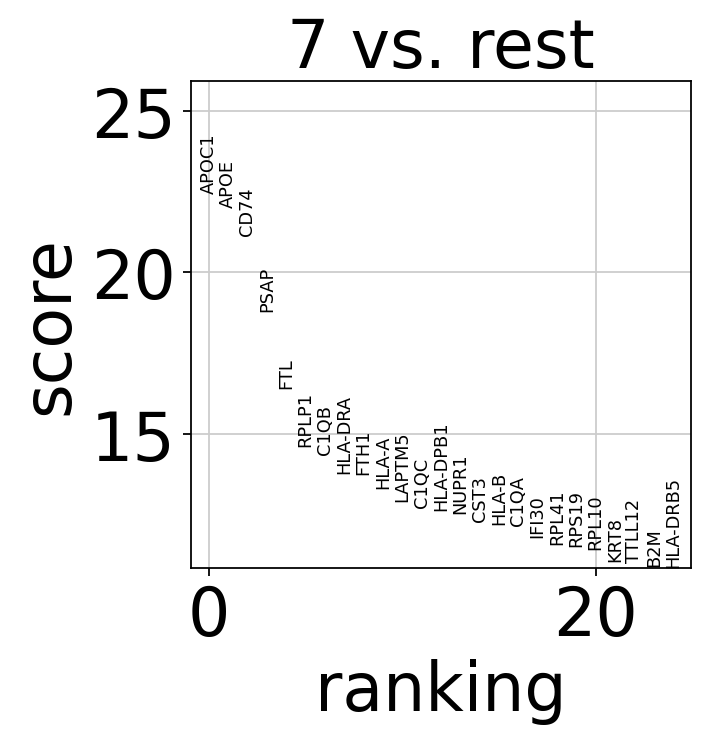

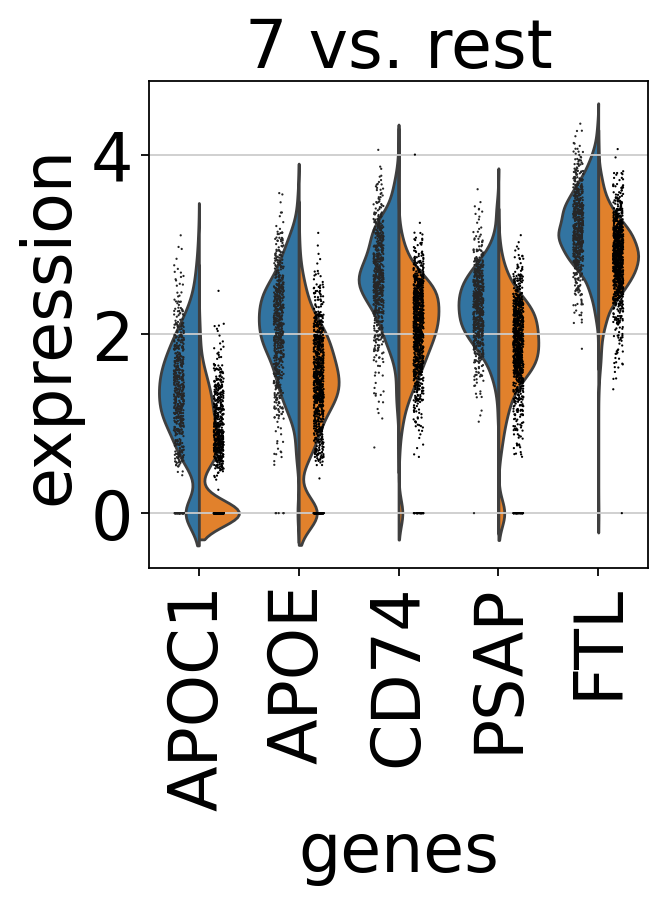

          names     scores  logfoldchanges         pvals     pvals_adj
0         APOC1  22.440399        1.820382  1.079718e-92  3.951877e-88
1          APOE  22.021107        1.317183  2.640021e-92  4.831370e-88
2          CD74  21.147699        0.963231  5.259155e-86  6.416345e-82
3          PSAP  18.794607        0.815548  9.880218e-71  6.027098e-67
4           FTL  16.404274        0.548054  4.923348e-55  2.252493e-51
...         ...        ...             ...           ...           ...
36596      ENO1 -13.199675       -0.707036  1.441698e-37  3.517839e-34
36597    PRRC2C -13.986680       -0.967488  9.019045e-42  3.000964e-38
36598      PGK1 -16.423246       -1.001087  9.338170e-56  4.882662e-52
36599  HSP90AA1 -19.016083       -0.536588  3.202788e-72  2.344505e-68
36600    MALAT1 -19.358721       -0.934203  2.909401e-74  2.662174e-70

[36601 rows x 5 columns]
Overexpressed oncogenes in domain 7:
['APOC1', 'APOE', 'CD74', 'PSAP', 'C1QB', 'HLA-DRA', 'LAPTM5', 'C1QC', 'HLA-DPB1', 'C

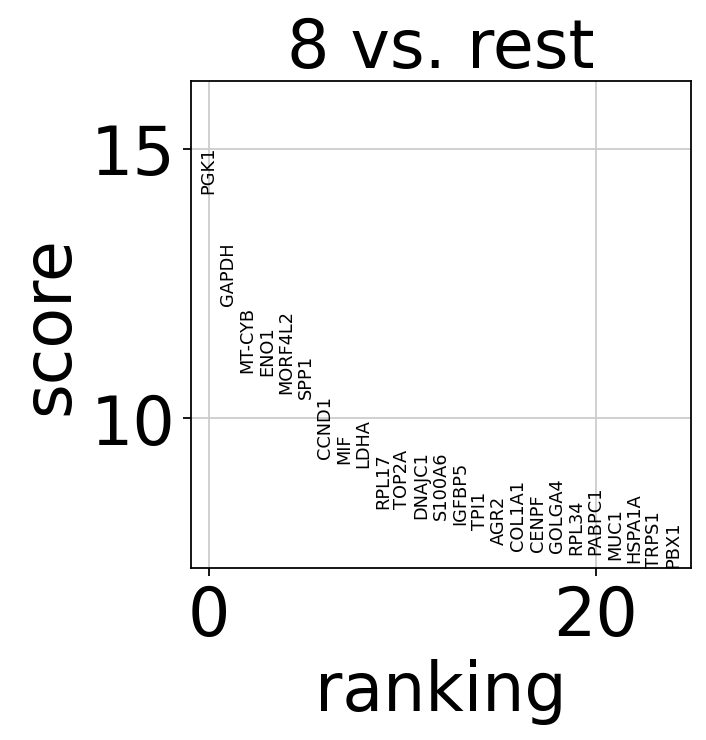

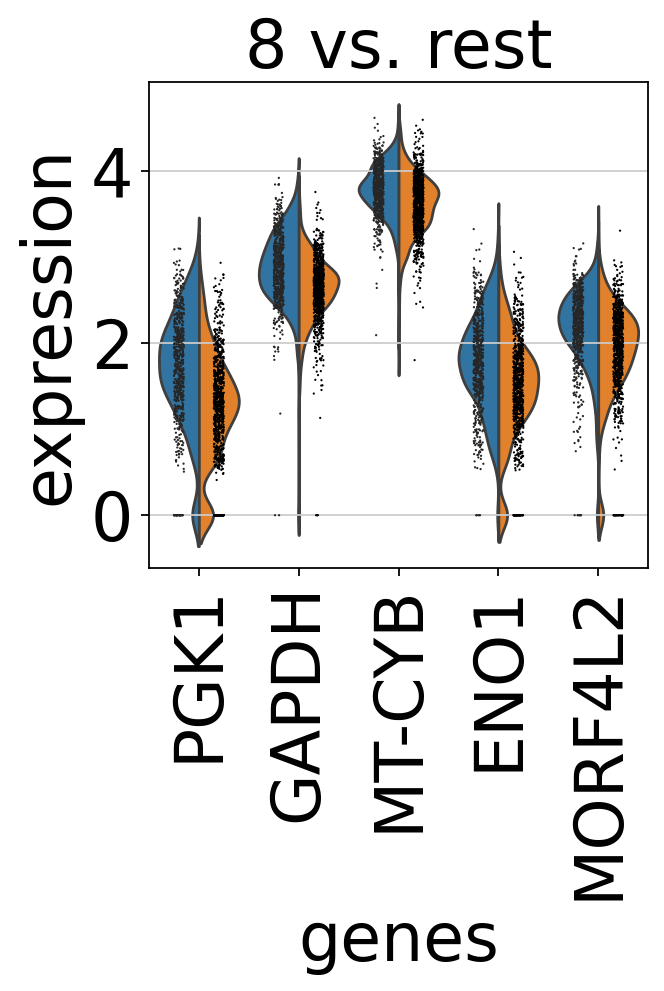

         names     scores  logfoldchanges         pvals     pvals_adj
0         PGK1  14.167877        0.905298  1.836901e-42  3.361621e-38
1        GAPDH  12.100565        0.396171  6.138421e-32  3.744539e-28
2       MT-CYB  10.844146        0.265024  2.225390e-26  1.018144e-22
3         ENO1  10.790833        0.584257  4.017663e-26  1.633894e-22
4      MORF4L2  10.467761        0.466435  9.300206e-25  3.403969e-21
...        ...        ...             ...           ...           ...
36596     CTSD -11.440656       -0.396509  5.176158e-29  2.706465e-25
36597     CD74 -12.650677       -0.621167  7.465264e-35  5.464722e-31
36598     APOE -12.763655       -0.839134  1.940267e-35  1.775393e-31
36599    APOC1 -13.200096       -1.156626  1.130188e-37  1.378867e-33
36600      FTL -14.471840       -0.489579  3.088757e-44  1.130516e-39

[36601 rows x 5 columns]
Overexpressed oncogenes in domain 8:
['PGK1', 'SPP1', 'CENPF', 'NUAK1', 'ZNF292', 'COL11A1', 'MIR210HG', 'ALDOA', 'CA11', 'ASPM', 'LOX

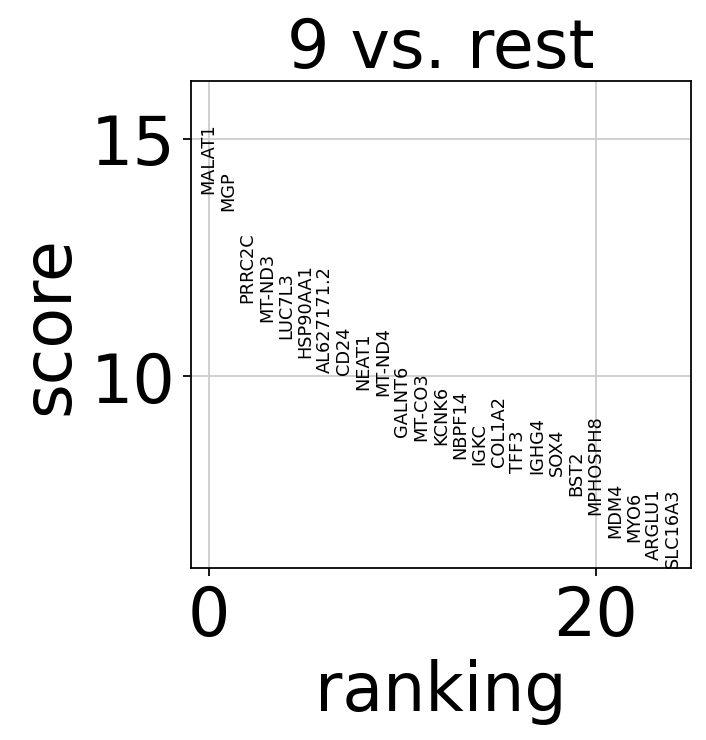

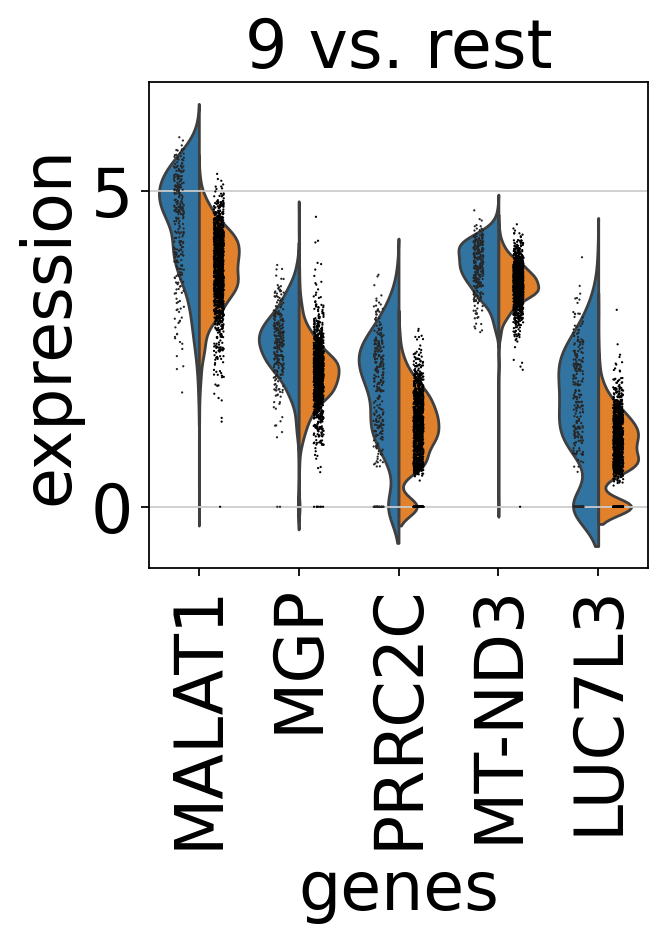

        names     scores  logfoldchanges         pvals     pvals_adj
0      MALAT1  13.846082        1.065298  6.737059e-35  1.232915e-30
1         MGP  13.494971        0.787694  3.711285e-34  3.395919e-30
2      PRRC2C  11.560260        1.212723  3.582708e-26  1.092756e-22
3      MT-ND3  11.154995        0.413732  4.928419e-25  1.127407e-21
4      LUC7L3  10.789198        1.357687  2.909791e-23  5.325063e-20
...       ...        ...             ...           ...           ...
36596   RPS14 -12.100554       -0.842973  7.337210e-28  3.836417e-24
36597   RPS27 -12.186110       -0.567777  2.920419e-28  1.781505e-24
36598   RPS20 -12.547735       -1.282503  1.137644e-29  8.327780e-26
36599   RPLP1 -13.878950       -0.850072  2.792179e-34  3.395919e-30
36600    KRT8 -13.920606       -0.539386  4.018799e-35  1.232915e-30

[36601 rows x 5 columns]
Overexpressed oncogenes in domain 9:
['MALAT1', 'MGP', 'PRRC2C', 'LUC7L3', 'AL627171.2', 'KCNK6', 'NBPF14', 'SOX4', 'MPHOSPH8', 'MYO6', 'ARGLU1', 

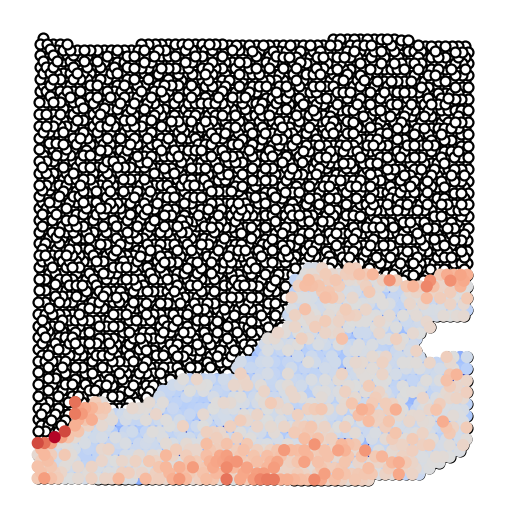

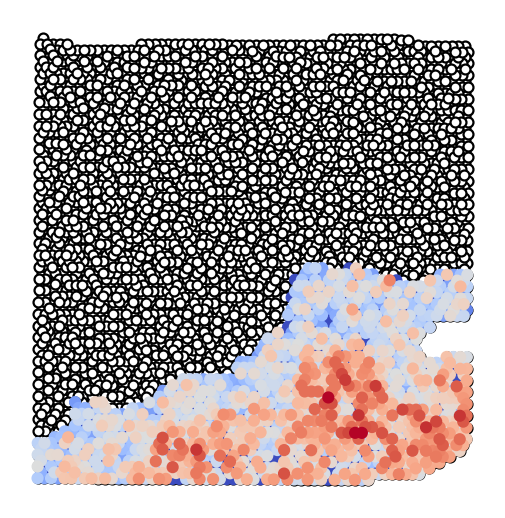

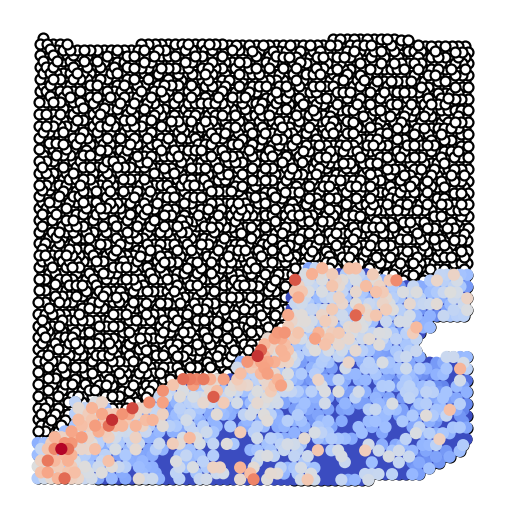

In [ ]:

#Run differential gene expression between domains 4 and 5
compare = ['7','8','9']
tt = []
for i in range(len(adata.obs['tumor_cat'])):
    if adata.obs['tumor_cat'].iloc[i] in compare:
        tt.append(i)
adata_temp = adata[tt,:]
for c in compare:
    sc.set_figure_params(scanpy=True, fontsize=30)
    sc.tl.rank_genes_groups(adata_temp,'tumor_cat',groups = [c],method='t-test', key_added = f"compare{c}",use_raw=False)
    sc.pl.rank_genes_groups(adata_temp, n_genes=25, sharey=False, key = f"compare{c}")
    ax=sc.pl.rank_genes_groups_violin(adata_temp,n_genes=5,save=False,key= f"compare{c}")    

    sig = sc.get.rank_genes_groups_df(adata_temp,group=[c],key = f"compare{c}")
    print(sig)
    genes = []
    lfc = []
    print(f'Overexpressed oncogenes in domain {c}:')
    for index,row in sig.iterrows():
        if  row['pvals_adj'] < 0.001 and row['logfoldchanges'] > 0.75:
            

                genes.append(row['names'])
                lfc.append(row['logfoldchanges'])
                
    
                    
    print(genes)
    print('Total:'+str(len(genes)))
names = ['MGP','PGK1','APOC1']
for name in names:
    adata_temp2 = adata_temp[:,[name]]
    
    plt.figure()
    plt.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1],c='white',s=20,edgecolors='k')
    order = np.argsort(adata_temp2.X.toarray(),axis=0)
    c = adata_temp2.X.toarray()[order]
    c = c/np.max(c)
    x = adata_temp2.obsm['spatial'][:,0][order]
    y = adata_temp2.obsm['spatial'][:,1][order]
    plt.scatter(x,y,c=c,cmap='coolwarm',s=20)
    #plt.title(name)
    a = plt.gca()
    a.axis('off')
    a.set_aspect('equal')
    #plt.colorbar(ticks=[0,1])
    genes.append(row['names'])
    plt.savefig(f'/home/pbeamer/Documents/phd-ms_files/figures/raw_output/multiscale/idc/{name}.png',bbox_inches='tight')

#print(len(adata.obs['tumor_cat'].cat.categories.tolist()))
